# Notebook 2 of 3 -- Project Walkthrough, Part 1: Replicating a Hybrid Rules + LLM Job-Posting Classifier and an Audit Baseline

This is the second notebook in a three-part project exploring a common production pattern: a
job-intelligence platform that surfaces hiring signals to job seekers using (a) rule-based
keyword-taxonomy heuristics and (b) an LLM classification tier called over raw HTTP as a fallback
for postings the rules cannot resolve. The goal is an **audit**: prompt quality, batching/chunking,
response validation, error handling, and "where is rule-based vs. LLM the right tool, and where
should the boundary between them shift". A further extension (not attempted here) would be
statistically grounded monitoring, a stated-content-vs-keyword-decoration classifier, and dedup at
100K+ scale -- that extension is Notebook 3.

**What's synthetic vs. real:**
- The corpus (postings, companies, phrasing) is **entirely synthetic**, generated with a known
  latent ground truth, precisely so the audit statistics in `## 6` and `## 7` below have
  something checkable to compare against. See `## Dataset rationale` for why.
- The LLM calls are **real**: every classification in this notebook is a live HTTP call to
  DeepSeek (`deepseek-flash`), not a stub. Calls are disk-cached under
  `../data/llm_cache/deepseek/` keyed by request body, so re-running this notebook after the
  first pass makes **zero** new live calls (see `LLM_STATS["live_calls"]` printed throughout,
  and the Claude-vs-DeepSeek mapping table in `## 3`).
- A hard cap (`MAX_LIVE_CALLS = 800`) protects the budget; approximate cost (peak DeepSeek
  pricing) is printed after each LLM-calling section.

**How this connects to the other two notebooks:** Notebook 1 holds the PPI /
BARGAIN / PPRM math. Notebook 3 (reusing the rules/generator/client code below
verbatim) adds guaranteed routing (BARGAIN), prediction-powered evaluation (PPI), and
harmful-drift monitoring (PPRM) on top of the pipeline built here. See the closing recap for the
exact hand-off.

## Project idea

The idea sketched out here is an **audit harness for a hybrid rules+LLM job-posting classifier**,
plus a first measurement/routing/monitoring layer on top of it:

1. Replicate the two-tier architecture at small scale: a deterministic keyword-taxonomy scorer
   (cheap, instant, but blind to paraphrase) feeding an LLM fallback (expensive, slower, but able
   to read intent) for postings the rules can't resolve.
2. Build a **known-ground-truth synthetic corpus** so precision/recall/coverage claims are
   checkable, not just plausible-sounding.
3. Run an **audit baseline**: prompt/response validation, a batching-strategy sweep,
   coverage by decision tier, and a simulated human-audit sample with confidence intervals.
4. Use the audit to ask the practical question: **where should the rules/LLM boundary
   move** -- which latent failure modes does each tier own?

The eventual deliverable this is building toward -- a written audit assessment backed by
these numbers, plus statistically-grounded routing/monitoring on top of it -- is **not** built in this
notebook. Notebook 3 picks up the routing (BARGAIN), evaluation (PPI), and drift-monitoring
(PPRM) layers; see the closing recap.

## Dataset rationale

The natural real-world stand-in for this problem is the Kaggle dataset **"LinkedIn Job Postings
(2023 - 2024)"** (`arshkon`),
https://www.kaggle.com/datasets/arshkon/linkedin-job-postings -- real postings with titles,
descriptions, and skills fields that would need a genai-substantive label applied by hand or by
this exact hybrid pipeline. (Its exact posting count is not stated here since it wasn't verified
for this notebook.)

It is **not downloaded here**. The reason is specific to what this notebook needs to measure: an audit
of precision/recall/coverage requires *known* ground truth to check the pipeline's decisions
against, and real LinkedIn postings would need exactly the labeling effort this pipeline is being
audited for -- a circularity. Instead, `## 1` below builds a **synthetic generator with known
latent truth**: every posting is stamped with the "true" answer at generation time, by
construction, so every claim in `## 6` and `## 7` ("the audit's 95% CI covers the true
population value", "rules miss class C") is a fact about the generator, checkable in this
notebook, rather than a claim about the real world. Swapping in the real Kaggle set (with real
human labels) is one of the "your decisions to make" items at the end.

In [1]:
%matplotlib inline
import hashlib
import json
import math
import os
import re
import threading
import time
import urllib.error
import urllib.request
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
from pydantic import BaseModel, ConfigDict, ValidationError

SEED = 20260917
RNG = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data"
CACHE_DIR = DATA_DIR / "llm_cache" / "deepseek"

# Consistent colour palette reused by every chart in this notebook.
PALETTE = {
    "A_genai_core": "#1f77b4",
    "B_decorated": "#ff7f0e",
    "C_genai_implicit": "#2ca02c",
    "D_plain": "#7f7f7f",
    "E_tool_user": "#d62728",
    "F_mixed_minor": "#8c564b",
    "G_mixed_major": "#e377c2",
    "H_classic_nlp_ml": "#17becf",
    "I_vague_ai_strategy": "#bcbd22",
    "pos": "#2ca02c",
    "neg": "#7f7f7f",
    "unresolved": "#ff7f0e",
    "label_1": "#2ca02c",
    "label_0": "#7f7f7f",
    "rule_pos": "#1f77b4",
    "rule_neg": "#7f7f7f",
    "llm": "#9467bd",
    "fallback_rule": "#d62728",
    "rules": "#1f77b4",
    "llm_line": "#d62728",
    "estimate": "#1f77b4",
    "truth": "#d62728",
    "current_hi": "#d62728",
}
CLASS_ORDER = [
    "A_genai_core", "B_decorated", "C_genai_implicit", "D_plain", "E_tool_user",
    "F_mixed_minor", "G_mixed_major", "H_classic_nlp_ml", "I_vague_ai_strategy",
]


def fmt_ci(ci):
    # Consistent 3-decimal CI formatting used everywhere a Wilson interval is printed.
    if ci is None:
        return "n/a"
    return f"[{ci[0]:.3f}, {ci[1]:.3f}]"


LABEL_GUIDE = (
    "genai_substantive = the role's actual RESPONSIBILITIES involve hands-on generative-AI / "
    "LLM work: building, fine-tuning, evaluating, or deploying LLM/GenAI systems, AS A CORE, "
    "ONGOING part of the job -- not a one-off or occasional task. Explicit edge-case policy "
    "(these are genuinely debatable; the policy below is the one gold label used in this "
    "notebook, and disagreement with it is itself a valid Phase-1 finding about guideline "
    "clarity, not an error in this notebook): "
    "(1) MIXED roles -- if at least two responsibilities are core, ongoing GenAI/LLM building "
    "work, the role IS substantive even if most of the job is unrelated. If only a single "
    "responsibility is an occasional/minor GenAI task among many unrelated ones, it is NOT "
    "substantive. "
    "(2) MERE TOOL USE -- using ChatGPT/Copilot/an AI assistant as a productivity tool, or "
    "listing GenAI buzzwords in a title, skills list, or company blurb without corresponding "
    "hands-on responsibilities, is NOT substantive. "
    "(3) CLASSIC/DISCRIMINATIVE ML or NLP -- text classifiers, named-entity recognition, topic "
    "models, or embeddings/vector databases used for search ranking or recommendations are NOT "
    "substantive, even though they share infrastructure vocabulary (embeddings, vector "
    "database) with generative work -- 'generative' specifically is required, not just "
    "'ML/NLP-adjacent'. "
    "(4) STRATEGY/EVANGELISM -- driving a GenAI roadmap, vendor partnerships, or transformation "
    "narrative without hands-on building/fine-tuning/evaluating/deploying is NOT substantive, "
    "no matter how much GenAI language the responsibilities use."
)
print(LABEL_GUIDE)

genai_substantive = the role's actual RESPONSIBILITIES involve hands-on generative-AI / LLM work: building, fine-tuning, evaluating, or deploying LLM/GenAI systems, AS A CORE, ONGOING part of the job -- not a one-off or occasional task. Explicit edge-case policy (these are genuinely debatable; the policy below is the one gold label used in this notebook, and disagreement with it is itself a valid Phase-1 finding about guideline clarity, not an error in this notebook): (1) MIXED roles -- if at least two responsibilities are core, ongoing GenAI/LLM building work, the role IS substantive even if most of the job is unrelated. If only a single responsibility is an occasional/minor GenAI task among many unrelated ones, it is NOT substantive. (2) MERE TOOL USE -- using ChatGPT/Copilot/an AI assistant as a productivity tool, or listing GenAI buzzwords in a title, skills list, or company blurb without corresponding hands-on responsibilities, is NOT substantive. (3) CLASSIC/DISCRIMINATIVE ML or 

In [2]:
TITLES_PLAIN = [
    "Software Engineer", "Backend Engineer", "Data Analyst", "Business Analyst",
    "Sales Operations Manager", "Financial Analyst", "QA Engineer", "Accountant",
    "Customer Success Manager", "Marketing Coordinator", "Supply Chain Analyst",
    "HR Generalist", "Project Coordinator", "Operations Manager", "Warehouse Supervisor",
    "Executive Assistant", "Legal Assistant", "Content Marketing Writer", "Recruiter",
    "Bookkeeper", "Network Administrator", "Store Manager",
    "Registered Nurse Case Manager", "Procurement Specialist", "Property Manager",
]
TITLES_AI_CORE = [  # genuine hands-on GenAI/ML titles, used only for class A
    "Machine Learning Engineer", "GenAI Engineer", "LLM Applications Engineer",
    "Prompt Engineer", "Applied Scientist, NLP", "AI Research Engineer",
    "Machine Learning Engineer, LLM Platform", "Generative AI Engineer",
]
TITLES_AI_DECORATED = [  # buzzwordy but non-core titles, used only for class B.
    # Each one deliberately contains a literal TAXONOMY term (genai / generative ai /
    # llm) so that "title hits" are a real, reproducible rule-tier false-positive path.
    "Data Analyst -- Generative AI Initiative", "GenAI-Curious Business Analyst",
    "LLM-Powered GenAI Business Analyst", "GenAI-Powered Business Analyst",
    "Business Analyst (Generative AI Insights Team)", "Sales Ops Analyst, GenAI Tools",
    "Data Analyst, GenAI-First Team",
]
TITLES_CLASSIC_ML = [  # non-generative ML/NLP titles, used only for class H
    "NLP Engineer", "Search Ranking Engineer", "Data Scientist, Search",
    "Machine Learning Engineer, Recommendations", "Applied Scientist, Search Ranking",
    "ML Engineer, Personalization", "Data Scientist, Recommendations",
    "NLP Research Engineer",
]
TITLES_AI_STRATEGY = [  # vague strategy/evangelist titles, used only for class I
    "Director of AI Strategy", "GenAI Product Manager", "AI Transformation Lead",
    "Head of AI Partnerships", "VP, AI Innovation", "AI Evangelist",
    "Generative AI Program Manager", "AI Strategy Consultant",
]
TITLES = (TITLES_PLAIN + TITLES_AI_CORE + TITLES_AI_DECORATED
          + TITLES_CLASSIC_ML + TITLES_AI_STRATEGY)  # kept for reference only

COMPANIES = [
    "Northwind Retail", "Bluepeak Logistics", "Cedarline Financial", "Harborview Health",
    "Meridian Analytics", "Fen & Co", "Grovemark Insurance", "Union Freight Co",
    "Silvercreek Media", "Larkspur Foods", "Ashford Manufacturing", "Vantage Robotics",
    "Redstone Capital", "Willow Tech", "Palisade Systems", "Ironclad Security",
    "Brightloop AI", "NeuralArc Labs", "Solace Data", "Quiver Cloud", "Tallgrass Energy",
    "Copperline Retailers",
]

LOCATIONS = [
    "Austin, TX", "Chicago, IL", "Remote (US)", "Denver, CO", "Seattle, WA",
    "Atlanta, GA", "Columbus, OH", "Raleigh, NC", "Phoenix, AZ", "Remote (EU)",
    "Boston, MA", "Minneapolis, MN", "Pittsburgh, PA", "Salt Lake City, UT",
    "Kansas City, MO", "Portland, OR",
]

EEO_SENTENCES = [
    "We are an equal opportunity employer and value diversity at our company.",
    "All qualified applicants will receive consideration without regard to race, color, "
    "religion, sex, national origin, disability, or veteran status.",
    "",
]
BENEFITS_LINES = [
    "Benefits include health/dental/vision, 401(k) match, and flexible PTO.",
    "We offer competitive pay, remote flexibility, and a generous learning stipend.",
    "",
]
AI_FIRST_BLURBS = [
    "We are an AI-first company applying generative AI across the business.",
    "Our AI-first culture means every team is exploring how LLM tooling can help.",
    "As an AI-first organization, we champion generative AI adoption company-wide.",
    "We describe ourselves as an AI-first company, weaving generative AI into our story.",
]
PLAIN_BLURBS = [
    "Join a growing team solving real problems for our customers.",
    "We move fast, ship often, and care about the details.",
    "",
]
ABOUT_US_PARAGRAPHS = [  # padding for realistic posting length; GenAI-neutral
    "Founded over a decade ago, we serve thousands of customers across North America and "
    "pride ourselves on a collaborative, low-ego culture where people stick around for years. "
    "Our leadership team has been mostly promoted from within, and we like it that way.",
    "We're a mid-sized, profitable company that has grown steadily without chasing hype -- "
    "our teams are small, our roadmaps are realistic, and we value people who ship. Most "
    "projects here are measured in weeks, not quarters, and everyone wears more than one hat.",
    "Our company operates across several regional offices and a growing remote workforce, "
    "with a strong focus on operational excellence and customer retention. We survey "
    "customers quarterly and hold every team accountable to what they hear back.",
    "We've built our reputation over many years on reliability and customer trust, and we're "
    "looking for people who care about doing the fundamentals well. Turnover on our team is "
    "low, and most of our current managers started in individual-contributor roles here.",
    "As a privately held company, we can take a long-term view -- we invest in our people, "
    "our processes, and steady, sustainable growth rather than short-term wins. We don't do "
    "layoffs to hit a quarterly number, and we've never had to walk that statement back.",
]
ROLE_SUMMARY_PARAGRAPHS = [  # always-on padding; GenAI-neutral
    "This role sits within a small, cross-functional team and reports to a working manager "
    "who still carries some of the same day-to-day responsibilities.",
    "You'll work closely with several other teams day to day, and the role is expected to "
    "flex somewhat as the department's priorities shift quarter to quarter.",
    "This is a full-time, individual-contributor role with occasional project-lead "
    "responsibilities depending on team capacity in a given quarter.",
    "The position reports into a director-level manager and collaborates regularly with "
    "adjacent teams on shared quarterly goals.",
    "We're looking for someone who can operate independently day to day while still asking "
    "for help early when a project runs into trouble.",
    "This role has a mix of recurring weekly responsibilities and occasional special "
    "projects assigned based on business need.",
]
HOW_TO_APPLY_PARAGRAPHS = [  # always-on padding; GenAI-neutral
    "To apply, submit a resume and a short note about why this role interests you; we "
    "aim to respond to every applicant within two weeks.",
    "Our interview process is typically three rounds: a recruiter screen, a hiring-manager "
    "conversation, and a small team panel -- usually completed within three weeks.",
    "Please apply through our careers page; we review applications on a rolling basis and "
    "will follow up regardless of outcome.",
    "We keep our hiring process short: a screening call, one working session, and a final "
    "conversation with the hiring manager -- typically two to three weeks end to end.",
]

# ---- Responsibility pools -------------------------------------------------

RESP_A = [
    "fine-tune large language models on proprietary support-ticket data",
    "build a RAG pipeline over internal documentation using a vector database",
    "design and iterate on prompt engineering strategies for production LLM features",
    "evaluate LLM outputs against human references and track hallucination rate",
    "deploy fine-tuned GPT-4 class models behind an internal inference API",
    "own the retrieval-augmented generation stack, from chunking to reranking",
    "build agentic workflows that chain multiple LLM calls and tool invocations",
    "implement embeddings-based semantic search to power a RAG chatbot",
    "run fine-tuning experiments comparing LoRA adapters across base LLMs",
    "prototype AI agents that plan and execute multi-step tasks autonomously",
    "build evaluation harnesses that score generative AI model outputs at scale",
    "design the prompt engineering guidelines used across all LLM features",
    "integrate a vector database into the retrieval-augmented generation pipeline",
    "train and fine-tune embeddings models for internal document search",
    "build and maintain the RAG-based question-answering system for support",
    "develop agentic AI workflows that orchestrate GPT-4 and internal tools",
    "own prompt engineering and evaluation for the generative AI assistant",
    "fine-tune open-source LLMs for domain-specific summarization tasks",
    "design the LLM serving infrastructure, including batching and caching",
    "build a large language model evaluation suite covering factuality and tone",
    "lead the generative AI roadmap for LLM-powered document drafting features",
    "implement retrieval-augmented generation with a hybrid vector database index",
    "build and fine-tune LLMs for structured data extraction from contracts",
    "design agentic AI pipelines with tool use, planning, and self-critique",
    "run prompt engineering experiments and measure downstream LLM accuracy",
    "build the GenAI feature layer: RAG, fine-tuning, and prompt engineering",
    "evaluate embeddings quality for a semantic search over a vector database",
    "develop and fine-tune LLMs to generate personalized product descriptions",
]
# Deliberately single-weak-term RESP_A phrases (score 0.5-0.8 alone), used only for the
# "borderline" A postings below so the sampling doesn't need TAXONOMY at generation time.
RESP_A_WEAK = [
    "deploy fine-tuned GPT-4 class models behind an internal inference API",
    "prototype AI agents that plan and execute multi-step tasks autonomously",
    "design agentic AI pipelines with tool use, planning, and self-critique",
]

RESP_B = [  # "B-responsibility" pool: non-GenAI, decorated class only
    "reconcile monthly ledger entries across three subsidiary accounts",
    "build and maintain churn-prediction models for the subscription business",
    "design BI dashboards tracking weekly revenue and retention metrics",
    "own the ETL pipelines that load nightly sales data into the warehouse",
    "manage the sales pipeline in the CRM and forecast quarterly bookings",
    "run QA test cycles for the mobile app before each release",
    "prepare quarterly financial statements and variance analysis",
    "coordinate vendor onboarding and manage procurement contracts",
    "audit customer support tickets for SLA compliance",
    "maintain the inventory forecasting spreadsheet across five warehouses",
    "process payroll and reconcile benefits deductions each pay period",
    "build regression-based demand forecasts for retail store planning",
    "manage the on-call rotation for the payments infrastructure team",
    "write and maintain SQL reports for the executive weekly business review",
    "coordinate cross-team logistics for product launches",
    "own the customer segmentation model used by the marketing team",
    "review loan applications against underwriting criteria",
    "manage the annual budget planning cycle across departments",
    "build dashboards tracking warehouse throughput and shipping SLAs",
    "administer the company's applicant tracking system",
    "conduct root-cause analysis on manufacturing defect reports",
    "maintain the general ledger and support external audits",
    "run A/B tests on checkout flow conversion rates",
    "manage vendor SLAs for the customer support outsourcing partner",
    "own the freight-cost allocation model across distribution centers",
    "coordinate the biweekly sprint planning for the platform team",
]

RESP_D = [  # plain, no GenAI, no buzzwords (kept distinct wording from B)
    "answer inbound customer calls and route escalations to the right team",
    "draft and proofread marketing copy for the weekly newsletter",
    "schedule interviews and coordinate candidate travel for onsite visits",
    "stock shelves and process returns during weekday shifts",
    "maintain office supply inventory and coordinate facilities requests",
    "prepare meeting agendas and take minutes for the leadership team",
    "process expense reports and reconcile corporate card statements",
    "greet visitors and manage the front-desk phone system",
    "train new hires on the point-of-sale system",
    "coordinate delivery schedules with regional freight carriers",
    "review legal contracts for standard clause compliance",
    "manage the company's social media posting calendar",
    "conduct patient intake and update electronic health records",
    "monitor network uptime and respond to hardware tickets",
    "run monthly payroll for hourly warehouse staff",
    "organize the quarterly all-hands meeting logistics",
    "process purchase orders and track delivery confirmations",
    "audit store inventory counts against point-of-sale records",
    "draft job descriptions and post open roles to job boards",
    "coordinate maintenance schedules for the delivery fleet",
    "handle tenant maintenance requests for the property portfolio",
    "prepare monthly newsletters for the homeowners association",
    "review insurance claims for completeness before adjuster review",
    "manage catering and logistics for client site visits",
    "update the employee handbook and onboarding checklist",
    "reconcile petty cash across three branch offices",
]

RESP_C = [  # implicit GenAI work, taxonomy terms avoided
    "design instructions that steer large pretrained text generators toward a target tone",
    "build systems that answer questions from internal documents using transformer models",
    "evaluate model-written summaries against human references for factual accuracy",
    "craft the wording sent to a hosted text-generation service to shape its output",
    "assemble a document-retrieval and answer-drafting system for internal knowledge",
    "tune adapter weights on a pretrained text-generation network for a support use case",
    "compare machine-drafted responses against gold-standard human answers",
    "wire together a search-then-summarize assistant over the company's knowledge base",
    "iterate on the phrasing given to a hosted text-generation API to improve outputs",
    "stand up a document question-answering assistant backed by a hosted text model",
    "adjust the weights of a pretrained transformer network on in-house support data",
    "score machine-generated draft replies for tone, accuracy, and completeness",
    "build a knowledge-lookup assistant that drafts answers from internal PDFs",
    "shape the instructions given to a hosted generative text service for consistency",
    "run offline comparisons of machine-drafted summaries versus analyst-written ones",
    "adapt a pretrained neural text generator to the company's support vocabulary",
    "build the retrieval layer that feeds context to a hosted text-generation service",
    "review machine-authored draft emails against a human-written style guide",
    "construct a pipeline that drafts responses using a hosted text-generation service",
    "measure how closely machine-drafted summaries match analyst reference summaries",
    "steer a pretrained text-generation network's outputs via curated example prompts",
    "build the document-chunking and lookup layer behind a text-drafting assistant",
    "calibrate a hosted text-generation service's tone against brand guidelines",
    "adjust a pretrained language network's behavior using curated instruction examples",
    "assemble evaluation sets to compare machine-drafted text against human drafts",
    "operate a text-generation service that drafts first-pass replies for review",
]
# ~1/3 of C postings additionally get exactly one weak taxonomy hit tacked onto one bullet
RESP_C_WEAK_SUFFIXES = [
    " (the underlying model exposes token embeddings we occasionally inspect)",
    ", occasionally cross-checking outputs against a GPT baseline for sanity",
    ", built on the same embeddings the search team already maintains",
]

RESP_E = [  # tool *use*, not building
    "use ChatGPT to draft first-pass marketing copy for campaigns",
    "rely on GitHub Copilot to speed up writing unit tests",
    "use generative AI tools like ChatGPT to draft first drafts of client proposals",
    "lean on AI assistants such as Copilot and ChatGPT to speed up daily report writing",
    "use ChatGPT to summarize long email threads before weekly syncs",
    "use Copilot to autocomplete boilerplate code during sprints",
    "ask ChatGPT to help brainstorm subject lines for outreach emails",
    "use an internal LLM-based tool to summarize customer call notes",
    "use AI assistants to speed up drafting internal wiki pages",
    "rely on ChatGPT for quick first drafts of status updates",
    "use Copilot suggestions to speed up writing SQL queries",
    "use generative AI chat tools to polish outgoing customer emails",
    "use an LLM-powered writing assistant to speed up proposal drafts",
    "turn to ChatGPT and Copilot for quick answers during debugging",
    "use AI assistants like ChatGPT to speed up meeting note summarization",
    "rely on LLM tools to draft the first pass of weekly status reports",
    "use ChatGPT to generate a first outline before writing final reports",
    "use Copilot to speed up scaffolding new service boilerplate",
    "ask an AI assistant to summarize vendor contracts before manual review",
    "use ChatGPT as a brainstorming partner for campaign ideas",
    "use generative AI (ChatGPT) to speed up first-pass translation of support replies",
    "rely on AI assistants for quick research summaries before client calls",
    "use Copilot and ChatGPT interchangeably to speed up day-to-day writing tasks",
    "use an LLM tool to auto-draft meeting recap emails",
    "occasionally use ChatGPT to check grammar on external communications",
    "use AI assistants to speed up formatting quarterly slide decks",
]

RESP_F_MINOR = [  # exactly one of these appears among 4-6 otherwise-plain bullets (label 0)
    "occasionally prototype LLM summaries of weekly reports",
    "help evaluate a vendor chatbot before a renewal decision",
    "pilot a GenAI writing tool for internal memos once a quarter",
    "join monthly syncs about the company's AI vendor evaluation",
    "test a new AI assistant for meeting notes as a side task",
    "assist procurement in scoring a shortlist of chatbot vendors",
    "sat in on a one-time demo of a generative AI proposal tool",
    "helped trial an LLM-based ticket-tagging plugin for a week",
    "gave feedback on a prototype GenAI search bar during a pilot",
    "filled out a survey comparing three AI writing assistants",
    "attended a lunch-and-learn on prompt engineering basics",
    "tried an AI meeting summarizer for a few weeks before dropping it",
    "reviewed a vendor's RAG demo and wrote up brief notes",
    "spent one afternoon testing a chatbot builder for support",
    "co-signed off on a small GenAI proof-of-concept with IT",
    "occasionally asks IT about the status of an LLM pilot",
    "helped draft acceptance criteria for a future chatbot rollout",
    "sat on a one-time panel evaluating generative AI note-takers",
    "briefly experimented with an AI drafting tool for one report",
    "flagged a vendor's LLM feature request to the product team once",
    "took part in a single usability test of an internal AI assistant",
    "reviewed a competitor's GenAI feature for a slide, once",
    "helped scope (but did not build) a future LLM chatbot project",
    "tested an AI-generated FAQ draft before it went to legal",
    "occasionally forwards interesting LLM news to the team",
    "sat through a vendor pitch for an embeddings-based search add-on",
]

RESP_G_CORE = [  # >=2 of these appear in an otherwise mixed role (label 1)
    "alongside other duties, fine-tune a support-ticket triage LLM",
    "build and maintain a small RAG assistant for the sales team",
    "design prompts that steer a hosted text generator for marketing drafts",
    "evaluate a pretrained assistant's draft replies against human answers",
    "part-time, own the prompt engineering for an internal chatbot",
    "build a lightweight retrieval-augmented generation tool for onboarding docs",
    "maintain embeddings-based search behind a small internal LLM assistant",
    "fine-tune a small open-source model for ticket classification and drafting",
    "prototype an agentic workflow that drafts and revises client emails",
    "adapt a pretrained text generator to draft first-pass contract summaries",
    "build evaluation scripts that score a chatbot's answers for accuracy",
    "wire a document-retrieval layer into a GenAI assistant for HR questions",
    "iterate on the system prompt for the team's internal LLM helper",
    "fine-tune embeddings for a small internal semantic search tool",
    "stand up a RAG-based FAQ bot alongside other quarterly projects",
    "tune a pretrained language model's outputs for the support team's tone",
    "build a small vector-database-backed assistant for policy lookups",
    "one of several duties: maintain the prompt library for a support chatbot",
    "design and test prompts for a generative drafting tool used by sales",
    "adjust a hosted model's instructions to reduce hallucinated answers",
    "build a proof-of-concept LLM agent that files simple support tickets",
    "fine-tune a summarization model for weekly internal digest emails",
    "own evaluation of a RAG assistant's citations for factual accuracy",
    "maintain a retrieval index that feeds a small internal chatbot",
    "build and iterate on prompts for an AI drafting tool, part of a broader role",
    "adapt an open-source LLM to answer internal policy questions",
]

RESP_H = [  # classic/discriminative ML-NLP (label 0), often taxonomy-term overlap
    "train BERT-based text classifiers for support-ticket routing",
    "build named-entity recognition models for contract review",
    "maintain topic models over historical support tickets",
    "build embeddings for search ranking relevance",
    "maintain a vector database powering product recommendations",
    "tune a transformer-based classifier for spam detection",
    "evaluate NER model precision and recall on labeled tickets",
    "build a learning-to-rank model using text embeddings",
    "maintain the embeddings pipeline behind product search",
    "build a vector database index for nearest-neighbor recommendations",
    "train a sentiment classifier on customer review text",
    "build a duplicate-ticket detector using text embeddings",
    "maintain a transformer-based intent classifier for the chat routing system",
    "tune embeddings for a semantic search product-matching pipeline",
    "build a topic-modeling pipeline over survey free-text responses",
    "maintain a vector database for similarity-based fraud detection",
    "train a classifier that tags support tickets by department",
    "build embeddings-based deduplication for the customer database",
    "evaluate a named-entity recognition model against a labeled test set",
    "own the search-ranking model that uses embeddings for relevance scoring",
    "build a vector database-backed recommendation service for the storefront",
    "maintain a text classification pipeline for content moderation",
    "tune a BERT-style encoder for document similarity scoring",
    "build embeddings for a job-title normalization pipeline",
    "maintain a vector database that powers the internal document search tool",
    "train and evaluate a topic-classification model for news articles",
]

RESP_I = [  # vague AI strategy / evangelism (label 0), strong taxonomy terms, no building
    "drive our generative AI transformation across the org",
    "own the roadmap for LLM-powered features",
    "partner with GenAI vendors to pilot new tools",
    "evangelize responsible generative AI adoption company-wide",
    "present our generative AI vision and roadmap to the board",
    "coordinate cross-functional generative AI transformation workshops",
    "manage vendor relationships for our LLM tooling partners",
    "define KPIs for the company's generative AI initiative",
    "represent the company at generative AI industry panels",
    "author the company's public generative AI point-of-view",
    "align stakeholders on the LLM strategy roadmap",
    "review RFPs from prompt engineering consultancies",
    "sponsor pilots with GenAI startups",
    "brief executives on the generative AI competitive landscape",
    "curate the company's internal generative AI newsletter",
    "set OKRs for GenAI adoption across business units",
    "chair the generative AI steering committee",
    "scout emerging LLM vendors for partnership",
    "negotiate contracts with generative AI platform vendors",
    "shape the company's public narrative on responsible AI",
    "facilitate executive workshops on generative AI opportunities",
    "own budget allocation for generative AI pilots",
    "track ROI metrics for GenAI pilot programs",
    "liaise between legal and vendors on GenAI compliance",
    "champion generative AI literacy training for staff",
    "build the business case for adopting agentic AI vendors",
]

REQUIREMENTS_GENERIC = [
    "2+ years of relevant professional experience",
    "bachelor's degree or equivalent practical experience",
    "strong written and verbal communication skills",
    "comfortable working cross-functionally with multiple stakeholders",
    "experience with spreadsheets and basic reporting tools",
    "ability to manage multiple priorities under deadlines",
    "attention to detail and a track record of follow-through",
]
REQUIREMENTS_A = [
    "hands-on experience fine-tuning or serving large language models",
    "experience building retrieval-augmented generation systems",
    "familiarity with prompt engineering and LLM evaluation methods",
    "experience with vector databases and embeddings-based retrieval",
    "prior work shipping generative AI features to production",
]
REQUIREMENTS_H = [
    "experience with classical NLP (NER, topic modeling, text classification)",
    "familiarity with embeddings for search or recommendation ranking",
    "experience maintaining a vector database in production",
    "background in learning-to-rank or recommendation systems",
]
REQUIREMENTS_I = [
    "experience presenting to senior executives and boards",
    "familiarity with the generative AI vendor landscape",
    "background in technology strategy or transformation programs",
    "comfortable setting roadmaps without hands-on engineering work",
]
SKILLS_GENERIC = [
    "Excel", "SQL", "PowerPoint", "Salesforce", "Slack", "Jira", "Zendesk",
    "QuickBooks", "Tableau", "Google Workspace", "Asana", "NetSuite",
]
SKILLS_A = [
    "LLM fine-tuning", "RAG", "Prompt Engineering", "Vector Databases", "PyTorch",
    "Embeddings", "LangChain", "GPT-4", "Agentic workflows",
]
SKILLS_BUZZ = [  # decorated skills for class B / some E
    "ChatGPT", "Copilot", "Generative AI", "GenAI", "Prompt Engineering (basic)",
]
SKILLS_H = [
    "Embeddings", "Vector Databases", "BERT", "scikit-learn", "spaCy", "PyTorch",
    "Learning-to-Rank", "NER",
]
SKILLS_I = [
    "Roadmapping", "Vendor Management", "Stakeholder Alignment", "OKRs",
    "Public Speaking", "Generative AI", "LLM", "GenAI",
]


MIXTURE_BY_MONTH = {m: {
    "A_genai_core": .10, "B_decorated": .07, "C_genai_implicit": .05, "D_plain": .50,
    "E_tool_user": .05, "F_mixed_minor": .06, "G_mixed_major": .05,
    "H_classic_nlp_ml": .07, "I_vague_ai_strategy": .05,
} for m in (1, 2, 3, 4)}
MIXTURE_BY_MONTH.update({m: {
    "A_genai_core": .10, "B_decorated": .18, "C_genai_implicit": .05, "D_plain": .33,
    "E_tool_user": .08, "F_mixed_minor": .08, "G_mixed_major": .05,
    "H_classic_nlp_ml": .06, "I_vague_ai_strategy": .07,
} for m in (5, 6)})

RESP_POOL_BY_CLASS = {
    "A_genai_core": RESP_A, "B_decorated": RESP_B, "C_genai_implicit": RESP_C,
    "D_plain": RESP_D, "E_tool_user": RESP_E, "F_mixed_minor": RESP_D,
    "G_mixed_major": RESP_D, "H_classic_nlp_ml": RESP_H, "I_vague_ai_strategy": RESP_D,
}


def _pick(rng, pool, n):
    idx = rng.choice(len(pool), size=n, replace=False)
    return [pool[i] for i in idx]


def _render(rec):
    lines = [rec["title"], rec["company"], rec["location"]]
    if rec["blurb"]:
        lines.append(rec["blurb"])
    if rec.get("about_us"):
        lines.append(rec["about_us"])
    if rec.get("role_summary"):
        lines.append(rec["role_summary"])
    if rec.get("_merge_paragraph"):
        lines.append("Responsibilities: " + " ".join(
            r if r.endswith((".", "!", "?")) else r + "." for r in rec["responsibilities"]))
    else:
        lines.append("Responsibilities:")
        lines += [f"- {r}" for r in rec["responsibilities"]]
    lines.append("Requirements:")
    lines += [f"- {r}" for r in rec["requirements"]]
    lines.append("Skills: " + ", ".join(rec["skills"]))
    if rec.get("_eeo"):
        lines.append(rec["_eeo"])
    if rec.get("_benefits"):
        lines.append(rec["_benefits"])
    if rec.get("how_to_apply"):
        lines.append(rec["how_to_apply"])
    return "\n".join(lines)


def _make_record(rng, rid, month, latent_class):
    company = rng.choice(COMPANIES)
    location = rng.choice(LOCATIONS)
    blurb = ""
    keyword_decorated = False
    label = 0

    if latent_class == "A_genai_core":
        label = 1
        # ~10% "borderline" A postings: a single weak-signal responsibility, plain
        # title, generic requirements/skills -- these are the ones that stay
        # unresolved instead of resolving "pos" (rules don't catch every true positive).
        borderline = rng.random() < 0.10
        if borderline:
            title = rng.choice(TITLES_PLAIN)
            responsibilities = list(_pick(rng, RESP_A_WEAK, 1))
            requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
            skills = list(_pick(rng, SKILLS_GENERIC, min(rng.integers(3, 6), len(SKILLS_GENERIC))))
        else:
            title = rng.choice(TITLES_AI_CORE)
            n_resp = rng.integers(3, 7)
            responsibilities = list(_pick(rng, RESP_A, min(n_resp, len(RESP_A))))
            requirements = list(_pick(rng, REQUIREMENTS_A, min(rng.integers(2, 4), len(REQUIREMENTS_A)))) + \
                list(_pick(rng, REQUIREMENTS_GENERIC, 1))
            skills = list(_pick(rng, SKILLS_A, min(rng.integers(3, 6), len(SKILLS_A)))) + \
                list(_pick(rng, SKILLS_GENERIC, min(rng.integers(1, 3), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "B_decorated":
        label = 0
        keyword_decorated = True
        # Guarantee at least one buzzword channel (title / skills / blurb) fires,
        # then layer on extras at random so some resolve "pos" (title-hit false
        # positives) and others stay "unresolved" (a single weak buzz signal).
        channel = rng.choice(["title", "skills", "blurb"])
        use_title = channel == "title" or rng.random() < 0.35
        use_skills = channel == "skills" or rng.random() < 0.55
        use_blurb = channel == "blurb" or rng.random() < 0.45
        title = rng.choice(TITLES_AI_DECORATED) if use_title else rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(3, 7)
        pool = RESP_B if rng.random() < 0.7 else RESP_D
        responsibilities = list(_pick(rng, pool, min(n_resp, len(pool))))
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        n_buzz_skills = rng.integers(1, 4) if use_skills else 0
        skills = list(_pick(rng, SKILLS_BUZZ, min(n_buzz_skills, len(SKILLS_BUZZ)))) + \
            list(_pick(rng, SKILLS_GENERIC, min(rng.integers(2, 5), len(SKILLS_GENERIC))))
        blurb = rng.choice(AI_FIRST_BLURBS) if use_blurb else rng.choice(PLAIN_BLURBS)

    elif latent_class == "C_genai_implicit":
        label = 1
        title = rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(3, 7)
        responsibilities = list(_pick(rng, RESP_C, min(n_resp, len(RESP_C))))
        if rng.random() < (1.0 / 3.0):
            i = rng.integers(0, len(responsibilities))
            responsibilities[i] = responsibilities[i] + rng.choice(RESP_C_WEAK_SUFFIXES)
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        skills = list(_pick(rng, SKILLS_GENERIC, min(rng.integers(4, 8), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "D_plain":
        label = 0
        title = rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(3, 7)
        responsibilities = list(_pick(rng, RESP_D, min(n_resp, len(RESP_D))))
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        skills = list(_pick(rng, SKILLS_GENERIC, min(rng.integers(4, 8), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "E_tool_user":
        label = 0
        title = rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(3, 7)
        n_tool = min(rng.integers(2, 4), n_resp)
        tool_bits = list(_pick(rng, RESP_E, n_tool))
        plain_bits = list(_pick(rng, RESP_D, min(n_resp - n_tool, len(RESP_D))))
        responsibilities = tool_bits + plain_bits
        rng.shuffle(responsibilities)
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        n_buzz_skills = rng.integers(0, 2)
        skills = list(_pick(rng, SKILLS_BUZZ, min(n_buzz_skills, len(SKILLS_BUZZ)))) + \
            list(_pick(rng, SKILLS_GENERIC, min(rng.integers(3, 6), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "F_mixed_minor":
        label = 0
        title = rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(4, 7)
        plain_bits = list(_pick(rng, RESP_D, min(n_resp - 1, len(RESP_D))))
        minor_bit = list(_pick(rng, RESP_F_MINOR, 1))
        responsibilities = plain_bits + minor_bit
        rng.shuffle(responsibilities)
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        skills = list(_pick(rng, SKILLS_GENERIC, min(rng.integers(4, 8), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "G_mixed_major":
        label = 1
        title = rng.choice(TITLES_PLAIN)
        n_resp = rng.integers(4, 7)
        n_core = min(rng.integers(2, 4), n_resp)
        core_bits = list(_pick(rng, RESP_G_CORE, n_core))
        plain_bits = list(_pick(rng, RESP_D, min(n_resp - n_core, len(RESP_D))))
        responsibilities = core_bits + plain_bits
        rng.shuffle(responsibilities)
        requirements = list(_pick(rng, REQUIREMENTS_GENERIC, min(rng.integers(2, 4), len(REQUIREMENTS_GENERIC))))
        skills = list(_pick(rng, SKILLS_GENERIC, min(rng.integers(3, 6), len(SKILLS_GENERIC))))
        if rng.random() < 0.4:
            skills += list(_pick(rng, SKILLS_A, min(rng.integers(1, 3), len(SKILLS_A))))
        blurb = rng.choice(PLAIN_BLURBS)

    elif latent_class == "H_classic_nlp_ml":
        label = 0
        title = rng.choice(TITLES_CLASSIC_ML)
        n_resp = rng.integers(3, 7)
        responsibilities = list(_pick(rng, RESP_H, min(n_resp, len(RESP_H))))
        requirements = list(_pick(rng, REQUIREMENTS_H, min(rng.integers(1, 3), len(REQUIREMENTS_H)))) + \
            list(_pick(rng, REQUIREMENTS_GENERIC, 1))
        skills = list(_pick(rng, SKILLS_H, min(rng.integers(2, 5), len(SKILLS_H)))) + \
            list(_pick(rng, SKILLS_GENERIC, min(rng.integers(1, 3), len(SKILLS_GENERIC))))
        blurb = rng.choice(PLAIN_BLURBS)

    else:  # I_vague_ai_strategy
        label = 0
        title = rng.choice(TITLES_AI_STRATEGY)
        n_resp = rng.integers(3, 6)
        responsibilities = list(_pick(rng, RESP_I, min(n_resp, len(RESP_I))))
        requirements = list(_pick(rng, REQUIREMENTS_I, min(rng.integers(1, 3), len(REQUIREMENTS_I)))) + \
            list(_pick(rng, REQUIREMENTS_GENERIC, 1))
        skills = list(_pick(rng, SKILLS_I, min(rng.integers(2, 4), len(SKILLS_I)))) + \
            list(_pick(rng, SKILLS_GENERIC, min(rng.integers(1, 3), len(SKILLS_GENERIC))))
        blurb = rng.choice(AI_FIRST_BLURBS) if rng.random() < 0.5 else rng.choice(PLAIN_BLURBS)

    eeo = rng.choice(EEO_SENTENCES)
    benefits = rng.choice(BENEFITS_LINES)
    about_us = rng.choice(ABOUT_US_PARAGRAPHS)
    role_summary = rng.choice(ROLE_SUMMARY_PARAGRAPHS)
    how_to_apply = rng.choice(HOW_TO_APPLY_PARAGRAPHS)
    merge_paragraph = rng.random() < 0.15
    thin = rng.random() < 0.05

    rec = {
        "id": f"P{rid:06d}", "month": month, "title": title, "company": company,
        "location": location, "responsibilities": responsibilities,
        "requirements": requirements, "skills": skills, "blurb": blurb,
        "latent_class": latent_class, "label": label,
        "keyword_decorated": keyword_decorated, "dup_of": None,
        "_eeo": eeo, "_benefits": benefits, "about_us": about_us,
        "role_summary": role_summary, "how_to_apply": how_to_apply,
        "_merge_paragraph": merge_paragraph,
    }
    if thin and len(rec["responsibilities"]) > 1:
        rec["responsibilities"] = list(_pick(rng, rec["responsibilities"], 1))
    rec["text"] = _render(rec)
    return rec


def _repost(rng, rid, month, original):
    rec = dict(original)
    rec["id"] = f"P{rid:06d}"
    rec["month"] = month
    rec["dup_of"] = original["id"]
    resp = list(original["responsibilities"])
    rng.shuffle(resp)
    if rng.random() < 0.5 and resp:
        i = rng.integers(0, len(resp))
        pool = RESP_POOL_BY_CLASS[original["latent_class"]]
        candidates = [p for p in pool if p not in resp]
        if candidates:
            resp[i] = rng.choice(candidates)
    rec["responsibilities"] = resp
    if rng.random() < 0.5:
        rec["location"] = rng.choice(LOCATIONS)
    if rng.random() < 0.3:
        rec["company"] = original["company"] + " (formerly listed)"
    if rng.random() < 0.4:
        rec["_eeo"] = rng.choice(EEO_SENTENCES)
        rec["_benefits"] = rng.choice(BENEFITS_LINES)
    rec["text"] = _render(rec)
    return rec


def generate_corpus(seed=20260917, n_per_month=800, months=range(1, 7),
                     mixture_by_month=None, dup_rate=0.20):
    if mixture_by_month is None:
        mixture_by_month = MIXTURE_BY_MONTH
    rng = np.random.default_rng(seed)
    records = []
    by_month = {m: [] for m in months}
    rid = 1
    for m in months:
        mix = mixture_by_month[m]
        classes = list(mix.keys())
        probs = np.array([mix[c] for c in classes], dtype=float)
        probs = probs / probs.sum()
        n_new = int(round(n_per_month * (1 - dup_rate)))
        n_repost = n_per_month - n_new
        assigned = rng.choice(classes, size=n_new, p=probs)
        for cls in assigned:
            rec = _make_record(rng, rid, m, cls)
            records.append(rec)
            by_month[m].append(rec)
            rid += 1
        # reposts: draw from this month's or previous month's originals
        prior_pool = [r for r in records if r["dup_of"] is None]
        for _ in range(n_repost):
            if not prior_pool:
                cls = rng.choice(classes, p=probs)
                rec = _make_record(rng, rid, m, cls)
            else:
                orig_idx = rng.integers(0, len(prior_pool))
                orig = prior_pool[orig_idx]
                rec = _repost(rng, rid, m, orig)
            records.append(rec)
            by_month[m].append(rec)
            rid += 1
    for r in records:
        r.pop("_eeo", None)
        r.pop("_benefits", None)
        r.pop("_merge_paragraph", None)
        r.pop("about_us", None)
        r.pop("role_summary", None)
        r.pop("how_to_apply", None)
    return records


ALL_POSTINGS = generate_corpus(seed=SEED, n_per_month=800, months=range(1, 7),
                                mixture_by_month=MIXTURE_BY_MONTH, dup_rate=0.20)
BY_ID = {p["id"]: p for p in ALL_POSTINGS}

reposts = sum(1 for p in ALL_POSTINGS if p["dup_of"] is not None)
print(f"total records: {len(ALL_POSTINGS)}")
print(f"unique (originals): {len(ALL_POSTINGS) - reposts}   reposts: {reposts}")

MONTHS = list(range(1, 7))
_class_by_month = Counter((p["month"], p["latent_class"]) for p in ALL_POSTINGS)
CLASS_COUNTS_BY_MONTH = {m: {c: _class_by_month[(m, c)] for c in CLASS_ORDER} for m in MONTHS}
LABEL_PREVALENCE_BY_MONTH = {}
for m in MONTHS:
    month_recs = [p for p in ALL_POSTINGS if p["month"] == m]
    LABEL_PREVALENCE_BY_MONTH[m] = {
        "n": len(month_recs), "prevalence": sum(p["label"] for p in month_recs) / len(month_recs),
    }

print("\nlatent_class counts by month:")
for m in MONTHS:
    print(f"  month {m}: {CLASS_COUNTS_BY_MONTH[m]}")

print("\nlabel prevalence (genai_substantive=1) by month:")
for m in MONTHS:
    row = LABEL_PREVALENCE_BY_MONTH[m]
    print(f"  month {m}: n={row['n']}  prevalence={row['prevalence']:.3f}")

print("\n2 rendered examples each of B_decorated, C_genai_implicit, E_tool_user:")
for cls in ["B_decorated", "C_genai_implicit", "E_tool_user"]:
    examples = [p for p in ALL_POSTINGS if p["latent_class"] == cls][:2]
    for ex in examples:
        print(f"\n---- {cls} :: {ex['id']} (label={ex['label']}) ----")
        print(ex["text"])

total records: 4800
unique (originals): 3840   reposts: 960

latent_class counts by month:
  month 1: {'A_genai_core': 69, 'B_decorated': 68, 'C_genai_implicit': 37, 'D_plain': 375, 'E_tool_user': 54, 'F_mixed_minor': 57, 'G_mixed_major': 46, 'H_classic_nlp_ml': 57, 'I_vague_ai_strategy': 37}
  month 2: {'A_genai_core': 79, 'B_decorated': 55, 'C_genai_implicit': 48, 'D_plain': 397, 'E_tool_user': 43, 'F_mixed_minor': 52, 'G_mixed_major': 34, 'H_classic_nlp_ml': 57, 'I_vague_ai_strategy': 35}
  month 3: {'A_genai_core': 83, 'B_decorated': 56, 'C_genai_implicit': 33, 'D_plain': 403, 'E_tool_user': 43, 'F_mixed_minor': 36, 'G_mixed_major': 47, 'H_classic_nlp_ml': 65, 'I_vague_ai_strategy': 34}
  month 4: {'A_genai_core': 80, 'B_decorated': 51, 'C_genai_implicit': 34, 'D_plain': 392, 'E_tool_user': 52, 'F_mixed_minor': 53, 'G_mixed_major': 40, 'H_classic_nlp_ml': 56, 'I_vague_ai_strategy': 42}
  month 5: {'A_genai_core': 77, 'B_decorated': 129, 'C_genai_implicit': 44, 'D_plain': 298, 'E_to

#### How to read this chart

Left: each bar is one month's 800 postings, stacked by `latent_class` share -- watch
`B_decorated` (orange) grow in months 5-6, the scripted "buzzword wave". Right: the dashed
line is `genai_substantive` prevalence by month -- it should stay roughly flat even as the
buzzword wave hits, because `B_decorated` postings are buzzwordy but **label 0**. A rule tier
that keys on keywords instead of responsibilities would see its false-positive rate rise in
months 5-6 even though the true prevalence didn't move -- that's the audit signal this chart
exists to make visible.

**On the four "definition-hard" classes (`F_mixed_minor`, `G_mixed_major`, `H_classic_nlp_ml`,
`I_vague_ai_strategy`):** these exist specifically so the corpus is not trivially separable.
`F`/`G` test the "how much GenAI work is enough" boundary in a mixed role; `H` tests whether the
rule tier (and the LLM) can tell *generative* from *discriminative* ML/NLP despite shared
vocabulary (`embeddings`, `vector database`); `I` tests whether talking about GenAI strategy gets
mistaken for doing GenAI work. `LABEL_GUIDE` above states one specific, explicit policy on each
of these. **A reasonable person could draw these lines differently -- and that disagreement is
itself a Phase-1 finding about the guideline's clarity, not a defect in this notebook.** An audit
that can't state its edge-case policy this precisely can't be checked for consistency at all.

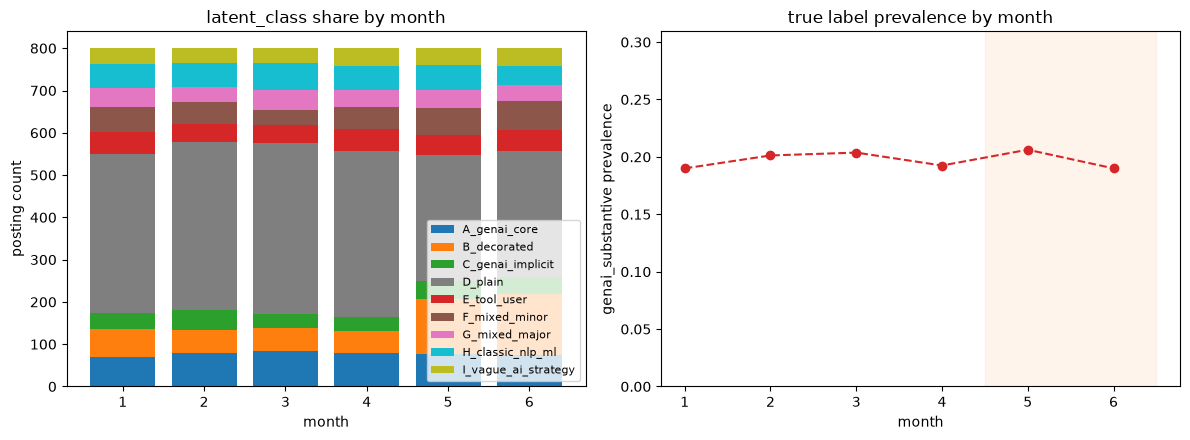

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

bottoms = np.zeros(len(MONTHS))
for cls in CLASS_ORDER:
    vals = np.array([CLASS_COUNTS_BY_MONTH[m][cls] for m in MONTHS])
    ax1.bar(MONTHS, vals, bottom=bottoms, label=cls, color=PALETTE[cls])
    bottoms += vals
ax1.set_xlabel("month")
ax1.set_ylabel("posting count")
ax1.set_title("latent_class share by month")
ax1.set_xticks(MONTHS)
ax1.legend(fontsize=8, loc="lower right")

prev = [LABEL_PREVALENCE_BY_MONTH[m]["prevalence"] for m in MONTHS]
ax2.plot(MONTHS, prev, marker="o", linestyle="--", color=PALETTE["truth"])
ax2.set_xlabel("month")
ax2.set_ylabel("genai_substantive prevalence")
ax2.set_title("true label prevalence by month")
ax2.set_xticks(MONTHS)
ax2.set_ylim(0, max(prev) * 1.5)
ax2.axvspan(4.5, 6.5, color=PALETTE["B_decorated"], alpha=0.08)

fig.tight_layout()
plt.show()

In [4]:
TAXONOMY = {
    "llm": 1.0, "llms": 1.0, "large language model": 1.0, "large language models": 1.0,
    "generative ai": 1.0, "genai": 1.0, "gpt": 0.5, "rag": 1.0,
    "retrieval-augmented generation": 1.0, "prompt engineering": 1.0, "fine-tuning": 0.8,
    "fine-tune": 0.8, "agentic": 0.8, "ai agents": 0.8, "chatgpt": 0.5, "copilot": 0.5,
    "embeddings": 0.6, "vector database": 0.6,
}
SECTION_WEIGHT = {"title": 2.0, "responsibilities": 3.0, "requirements": 1.0, "skills": 0.5, "blurb": 0.3}
TERM_PATTERNS = {t: re.compile(r"\b" + re.escape(t) + r"\b", re.IGNORECASE) for t in TAXONOMY}


def rule_score(posting: dict) -> tuple[float, dict]:
    # Returns (score, {section: [matched terms]}). Case-insensitive, word-boundary
    # matching; each term counted once per section.
    matched = {}
    total = 0.0
    for section, weight in SECTION_WEIGHT.items():
        val = posting.get(section, "")
        text = "\n".join(val) if isinstance(val, list) else (val or "")
        hits = [t for t, pat in TERM_PATTERNS.items() if pat.search(text)]
        if hits:
            matched[section] = hits
            total += weight * sum(TAXONOMY[t] for t in hits)
    return total, matched


def rule_decision(score: float, hi: float = 4.0, lo: float = 0.0) -> str:
    if score >= hi:
        return "pos"
    if score <= lo:
        return "neg"
    return "unresolved"


DECISIONS = ["pos", "neg", "unresolved"]
RULE_SCORES = {}
RULE_MATCHES = {}
RULE_DECISIONS = {}
for p in ALL_POSTINGS:
    score, matched = rule_score(p)
    RULE_SCORES[p["id"]] = score
    RULE_MATCHES[p["id"]] = matched
    RULE_DECISIONS[p["id"]] = rule_decision(score)

CONTINGENCY = {c: {d: 0 for d in DECISIONS} for c in CLASS_ORDER}
for p in ALL_POSTINGS:
    CONTINGENCY[p["latent_class"]][RULE_DECISIONS[p["id"]]] += 1

print(f"{'latent_class':<20}" + "".join(f"{d:>12}" for d in DECISIONS) + f"{'total':>10}")
for c in CLASS_ORDER:
    row = CONTINGENCY[c]
    tot = sum(row.values())
    print(f"{c:<20}" + "".join(f"{row[d]:>12}" for d in DECISIONS) + f"{tot:>10}")

n_unresolved = sum(1 for p in ALL_POSTINGS if RULE_DECISIONS[p["id"]] == "unresolved")
print(f"\nunresolved share: {n_unresolved}/{len(ALL_POSTINGS)} = {n_unresolved/len(ALL_POSTINGS):.3f}")

latent_class                 pos         neg  unresolved     total
A_genai_core                 424           0          38       462
B_decorated                   35           0         468       503
C_genai_implicit               0         166          70       236
D_plain                        0        2163           0      2163
E_tool_user                  136           1         153       290
F_mixed_minor                  0         149         181       330
G_mixed_major                123          20         106       249
H_classic_nlp_ml             103           4         231       338
I_vague_ai_strategy          214           0          15       229

unresolved share: 1262/4800 = 0.263


#### How to read this chart

Left: for each latent class, how the rule tier resolved it (green=pos, grey=neg,
orange=unresolved) -- a well-behaved rule tier would put all of `A_genai_core`'s mass in
green and all of `D_plain`'s in grey. Watch `C_genai_implicit` (paraphrased GenAI work) land
mostly grey/orange -- that's the rule tier's blind spot -- and `B_decorated` /
`E_tool_user` picking up unexpected green -- that's its false-positive path. Right: the
histogram of raw `rule_score` split by true label; the two vertical lines are the `lo`/`hi`
thresholds (0 and 4). Overlap of the green (label=1) and grey (label=0) histograms inside the
thresholds is exactly the "unresolved" zone the LLM tier exists to adjudicate.

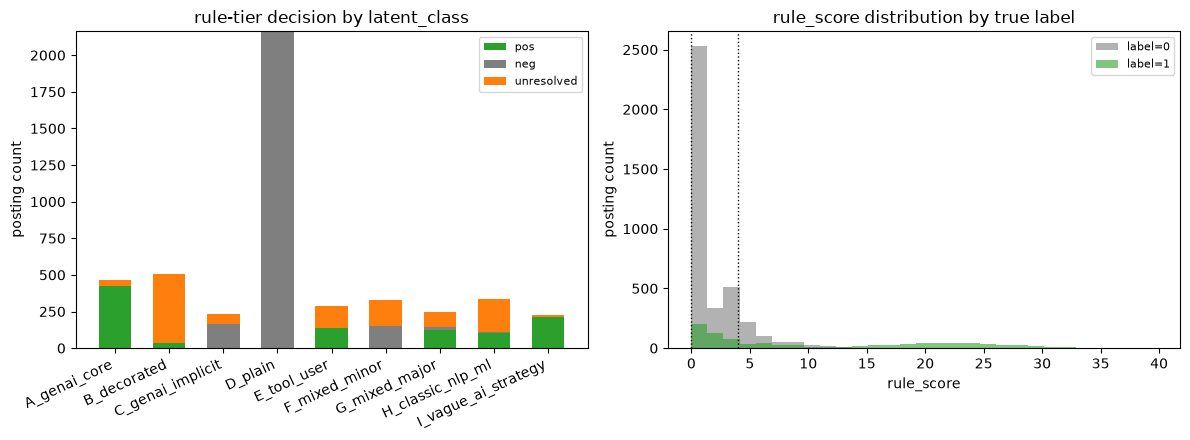

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

x = np.arange(len(CLASS_ORDER))
width = 0.6
bottoms = np.zeros(len(CLASS_ORDER))
for d in DECISIONS:
    vals = np.array([CONTINGENCY[c][d] for c in CLASS_ORDER])
    ax1.bar(x, vals, width, bottom=bottoms, label=d, color=PALETTE[d])
    bottoms += vals
ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_ORDER, rotation=25, ha="right")
ax1.set_ylabel("posting count")
ax1.set_title("rule-tier decision by latent_class")
ax1.legend(fontsize=8)

scores_1 = [RULE_SCORES[p["id"]] for p in ALL_POSTINGS if p["label"] == 1]
scores_0 = [RULE_SCORES[p["id"]] for p in ALL_POSTINGS if p["label"] == 0]
bins = np.linspace(0, max(RULE_SCORES.values()) + 0.5, 30)
ax2.hist(scores_0, bins=bins, alpha=0.6, label="label=0", color=PALETTE["label_0"])
ax2.hist(scores_1, bins=bins, alpha=0.6, label="label=1", color=PALETTE["label_1"])
ax2.axvline(0.0, color="black", linestyle=":", linewidth=1)
ax2.axvline(4.0, color="black", linestyle=":", linewidth=1)
ax2.set_xlabel("rule_score")
ax2.set_ylabel("posting count")
ax2.set_title("rule_score distribution by true label")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 3. The LLM tier: raw HTTP, no SDK

Many production classifiers of this shape call **Claude** over raw HTTP (no SDK) as the LLM
fallback. This notebook makes real classification calls to **DeepSeek** (`deepseek-flash`)
instead -- cheap enough to label every posting for real while prototyping -- so the client
wrapper built below (`## C4`) talks to DeepSeek, not Claude. The table below is a mapping/contrast
exercise: what would change if this exact client were pointed at Claude instead. Facts below are
as verified from Anthropic's docs (not executed against a live Claude endpoint in this notebook):

| | **Claude** | **DeepSeek** (this notebook's real target) |
|---|---|---|
| Endpoint | `POST https://api.anthropic.com/v1/messages` | `POST https://api.deepseek.com/chat/completions` |
| Auth headers | `x-api-key`, `anthropic-version: 2023-06-01`, `content-type: application/json` | `Content-Type: application/json`, `Authorization: Bearer <key>` |
| System prompt | top-level `system` string field (not a message) | a `"system"`-role entry inside `messages` |
| Structured output | `output_config: {"format": {"type": "json_schema", "schema": {...}}}`, `additionalProperties: false` required on every object (Claude Haiku 4.5 / Sonnet 5 / Opus 5) -- schema-**enforced** | `response_format: {"type": "json_object"}` -- shape only enforced by the prompt text + client-side pydantic validation, **not** by the API |
| Response text | `content[].text` where `type == "text"` | `choices[0].message.content` (a string -- and per DeepSeek's own docs, this **can be empty**, a known JSON-mode issue this notebook's `classify_batch` explicitly handles as `empty_content`) |
| Stop/finish reason | `stop_reason` ∈ `end_turn`, `max_tokens`, `stop_sequence`, `tool_use`, `refusal` | `finish_reason` ∈ `stop`, `length`, `content_filter`, `tool_calls`, `insufficient_system_resource`, `aborted` |
| Usage fields | `input_tokens`, `output_tokens` | `prompt_tokens`, `completion_tokens`, `total_tokens`, `prompt_cache_hit_tokens`, `prompt_cache_miss_tokens` |
| Confidence signal | **no log-probability field** in the Messages API response -- a Claude-based confidence score has to be constructed another way (Notebook 3 discusses this, for BARGAIN's proxy-score requirement) | `logprobs: true`, `top_logprobs: 0-20` -- token log-probabilities are available directly |
| Batch API | Message Batches API, `POST /v1/messages/batches`, `requests: [{custom_id, params}]`, 50% cost reduction on all token usage, most batches finish within 1 hour (max 24h), results keyed by `custom_id`, result types `succeeded`/`errored`/`canceled`/`expired` | no equivalent used in this notebook -- `classify_postings` below does its own client-side chunking + a `ThreadPoolExecutor` instead |

The practical upshot for Notebook 3's BARGAIN-style routing: BARGAIN's proxy score needs a
confidence signal. DeepSeek exposes `logprobs` directly; Claude does not, so a Claude-based proxy
would need a different confidence construction (e.g. self-consistency across repeated calls, or a
verbalized confidence in the JSON schema) -- Notebook 3's problem, not this one's.

**On proxy-score calibration (BARGAIN, Section 2.2):** BARGAIN's proxy score there is literally
"the output tokens' probability" -- the same DeepSeek `logprobs` this client already requests.
BARGAIN's own paper is explicit that this matters for *usefulness*, not *validity*: *"the use of
proxy scores to decide whether to use the proxy or not is beneficial only if the model is
well-calibrated ... Although our guarantees on output quality always hold even when the models are
not calibrated, in such cases, the cascade framework is unlikely to provide high utility."* So if
DeepSeek's logprobs turn out saturated (e.g. near-0/near-1 for almost everything, which is
plausible on a task this notebook's own audit found the model very accurate on), that is a
**utility** problem for Notebook 3's routing (fewer oracle calls avoided) -- not a **validity**
problem (BARGAIN's guarantee on output quality would still hold). This notebook does not implement
or test that claim; it only carries the distinction forward for Notebook 3.

In [6]:
DEEPSEEK_URL = "https://api.deepseek.com/chat/completions"
MODEL = "deepseek-flash"
MAX_LIVE_CALLS = 2500  # raised from 800 so ## 7 can LLM-label every posting, not just a sample

_STATS_LOCK = threading.Lock()


class LiveCallBudgetExceeded(RuntimeError):
    pass


class MissingAPIKey(RuntimeError):
    pass


LLM_STATS = {
    "live_calls": 0, "cache_hits": 0, "prompt_cache_hit_tokens": 0,
    "prompt_cache_miss_tokens": 0, "completion_tokens": 0, "http_retries": 0,
    "cached_completion_tokens": 0,  # informational only -- NOT billed, excluded from llm_cost_usd
}

# USAGE_LEDGER records the usage of EVERY response this notebook obtains, live or cached,
# tagged with which section/kind of request it was. Unlike LLM_STATS (session spend --
# zero on a warm-cache re-run), the ledger's cost reflects what the classification work
# itself cost when the tokens were originally produced, so per-section cost/token tables
# stay meaningful across cached re-runs. USED_CACHE_KEYS records every cache key this run
# touched (live or hit), so a maintainer can safely prune cache files nothing references.
USAGE_LEDGER = []
USED_CACHE_KEYS = set()


def _find_dotenv_key():
    # Walk up from the notebook's cwd looking for a .env with DEEPSEEK_KEY=...
    here = NOTEBOOK_DIR
    for d in [here] + list(here.parents):
        candidate = d / ".env"
        if candidate.exists():
            for line in candidate.read_text().splitlines():
                if line.startswith("DEEPSEEK_KEY="):
                    return line.split("=", 1)[1].strip()
    return None


def _get_api_key():
    return os.environ.get("DEEPSEEK_KEY") or _find_dotenv_key()


def _cache_key(body):
    payload = json.dumps(body, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _cache_path(key):
    return CACHE_DIR / key[:2] / f"{key}.json"


def deepseek_chat(body: dict, section: str = "unspecified", kind: str = "batch") -> dict:
    # POST to the DeepSeek chat/completions endpoint, disk-cached by request body hash.
    # Never logs, prints, or caches the API key itself. `section`/`kind` are only used to
    # tag USAGE_LEDGER entries (added to; the original single-arg call signature keeps working).
    key = _cache_key(body)
    path = _cache_path(key)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            cached = json.load(f)
        resp = cached["response"]
        usage = resp.get("usage", {})
        with _STATS_LOCK:
            LLM_STATS["cache_hits"] += 1
            # Cache hits are free -- do NOT add to the billed completion_tokens counter
            # that llm_cost_usd reads from. Tracked separately, informationally only.
            LLM_STATS["cached_completion_tokens"] += usage.get("completion_tokens", 0)
            USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": True, "usage": usage})
            USED_CACHE_KEYS.add(key)
        return resp

    with _STATS_LOCK:
        if LLM_STATS["live_calls"] >= MAX_LIVE_CALLS:
            raise LiveCallBudgetExceeded(
                f"MAX_LIVE_CALLS ({MAX_LIVE_CALLS}) exceeded -- refusing further live DeepSeek calls."
            )
    api_key = _get_api_key()
    if api_key is None:
        raise MissingAPIKey(
            "DEEPSEEK_KEY not found (checked env var and .env files walking up from cwd) "
            "and this request is a cache miss -- cannot make a live call."
        )

    data = json.dumps(body).encode("utf-8")
    req = urllib.request.Request(
        DEEPSEEK_URL, data=data, method="POST",
        headers={"Content-Type": "application/json", "Authorization": f"Bearer {api_key}"},
    )
    delays = [1, 2, 4, 8]
    last_err = None
    for attempt in range(4):
        try:
            with urllib.request.urlopen(req, timeout=120) as f:
                resp = json.loads(f.read().decode("utf-8"))
            usage = resp.get("usage", {})
            with _STATS_LOCK:
                LLM_STATS["live_calls"] += 1
                LLM_STATS["prompt_cache_hit_tokens"] += usage.get("prompt_cache_hit_tokens", 0)
                LLM_STATS["prompt_cache_miss_tokens"] += usage.get("prompt_cache_miss_tokens", 0)
                LLM_STATS["completion_tokens"] += usage.get("completion_tokens", 0)
                USAGE_LEDGER.append({"section": section, "kind": kind, "cache_hit": False, "usage": usage})
                USED_CACHE_KEYS.add(key)
            tmp_path = path.with_suffix(f".{threading.get_ident()}.tmp")
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(tmp_path, "w", encoding="utf-8") as f:
                json.dump({"request": body, "response": resp}, f)
            os.replace(tmp_path, path)
            return resp
        except (urllib.error.URLError, urllib.error.HTTPError) as e:
            last_err = e
            code_ = getattr(e, "code", None)
            if code_ is not None and code_ != 429 and not (500 <= code_ < 600):
                raise
            with _STATS_LOCK:
                LLM_STATS["http_retries"] += 1
            if attempt < 3:
                time.sleep(delays[attempt])
    raise RuntimeError(f"DeepSeek call failed after 4 attempts: {last_err}")


def llm_cost_usd(stats: dict, peak: bool = True) -> float:
    if peak:
        in_hit, in_miss, out = 0.006, 0.30, 1.20
    else:
        in_hit, in_miss, out = 0.003, 0.15, 0.60
    return (
        stats["prompt_cache_hit_tokens"] / 1e6 * in_hit
        + stats["prompt_cache_miss_tokens"] / 1e6 * in_miss
        + stats["completion_tokens"] / 1e6 * out
    )


def ledger_cost_usd(entries: list, peak: bool = True) -> float:
    # Cost of the classification WORK represented by `entries`, regardless of whether any
    # given entry was a live call or a cache hit this session -- "what the requests cost
    # when they were made" (unlike LLM_STATS, which is session spend and is ~0 on a warm
    # cache). Uses the same peak/off-peak pricing as llm_cost_usd.
    if peak:
        in_hit, in_miss, out = 0.006, 0.30, 1.20
    else:
        in_hit, in_miss, out = 0.003, 0.15, 0.60
    total = 0.0
    for e in entries:
        u = e.get("usage", {})
        total += (
            u.get("prompt_cache_hit_tokens", 0) / 1e6 * in_hit
            + u.get("prompt_cache_miss_tokens", 0) / 1e6 * in_miss
            + u.get("completion_tokens", 0) / 1e6 * out
        )
    return total


# Smoke test: one tiny real call, cached from here on.
_smoke_body = {
    "model": MODEL,
    "messages": [
        {"role": "system", "content": 'Return json only, exactly: {"ok": true}'},
        {"role": "user", "content": "ping. Return json."},
    ],
    "max_tokens": 50, "temperature": 0,
    "thinking": {"type": "disabled"},
    "response_format": {"type": "json_object"},
}
_smoke_resp = deepseek_chat(_smoke_body, section="setup", kind="smoke_test")
print("smoke test finish_reason:", _smoke_resp["choices"][0]["finish_reason"])
print("smoke test content:", _smoke_resp["choices"][0]["message"]["content"])
print("LLM_STATS:", LLM_STATS)

smoke test finish_reason: stop
smoke test content: {"ok": true}
LLM_STATS: {'live_calls': 0, 'cache_hits': 1, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 5}


In [7]:
SYSTEM_PROMPT = f'''You are auditing job postings for a hiring-signal platform. Classify \
each posting for whether it is genai_substantive.

Definition: {LABEL_GUIDE}

Rules:
- Judge ONLY the Responsibilities section for substantive GenAI/LLM work.
- Ignore GenAI buzzwords that appear only in the title, skills list, or company blurb --
  those do not make a posting substantive on their own.
- Merely USING a tool such as ChatGPT or Copilot to speed up otherwise-ordinary work is
  NOT substantive, even if the responsibilities mention it.
- Return json only, exactly this shape: {{"results": [{{"id": "<id>", \
"genai_substantive": true|false, "evidence": "<=15 words quoted from the posting"}}]}}'''


class ItemLabel(BaseModel):
    model_config = ConfigDict(extra="forbid")
    id: str
    genai_substantive: bool
    evidence: str


class BatchResult(BaseModel):
    model_config = ConfigDict(extra="forbid")
    results: list[ItemLabel]


FAILURE_COUNTS = Counter()


def _user_message(postings):
    parts = [f"### id={p['id']}\n{p['text']}" for p in postings]
    return "\n\n".join(parts)


def classify_batch(postings: list[dict], section: str = "unspecified", kind: str = "batch") -> list[dict]:
    # One DeepSeek API call classifying `postings`. Returns a list of
    # {id, genai_substantive, evidence, status} dicts, one entry per requested posting.
    # `section`/`kind` tag the USAGE_LEDGER entry for this call (added to; existing
    # single-arg callers keep working since both default).
    k = len(postings)
    requested_ids = [p["id"] for p in postings]
    body = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": _user_message(postings)},
        ],
        "max_tokens": 120 * k + 200,
        "temperature": 0,
        "thinking": {"type": "disabled"},
        "response_format": {"type": "json_object"},
    }

    def fail_all(status):
        return [{"id": pid, "genai_substantive": None, "evidence": None, "status": status}
                for pid in requested_ids]

    try:
        resp = deepseek_chat(body, section=section, kind=kind)
    except (LiveCallBudgetExceeded, MissingAPIKey):
        raise
    except Exception:
        return fail_all("http_error")

    choice = resp["choices"][0]
    content = choice["message"]["content"]
    finish_reason = choice["finish_reason"]
    truncated = finish_reason == "length"

    if not content:
        return fail_all("empty_content")
    try:
        raw = json.loads(content)
    except json.JSONDecodeError:
        return fail_all("truncated" if truncated else "json_parse_error")
    try:
        parsed = BatchResult.model_validate(raw)
    except ValidationError:
        return fail_all("truncated" if truncated else "schema_violation")

    out = []
    seen_ids = set()
    requested_set = set(requested_ids)
    for item in parsed.results:
        if item.id in seen_ids:
            status = "duplicate_id"
        elif item.id not in requested_set:
            status = "unexpected_id"
        else:
            status = "ok"
        seen_ids.add(item.id)
        out.append({"id": item.id, "genai_substantive": item.genai_substantive,
                     "evidence": item.evidence, "status": status})
    for pid in requested_ids:
        if pid not in seen_ids:
            out.append({"id": pid, "genai_substantive": None, "evidence": None,
                         "status": "truncated" if truncated else "missing_id"})
    return out


def classify_postings(postings: list[dict], k: int = 10, section: str = "unspecified") -> dict:
    # Chunks postings into batches of size k, runs classify_batch across a thread pool,
    # then repairs (resends individually, k=1) anything that wasn't status='ok'. Items
    # still failing after repair get status='failed' (pipeline falls back to the rule
    # decision for those, with status='fallback_rule' -- see ## 5). Failure taxonomy
    # counts accumulate in the module-level FAILURE_COUNTS. `section` tags every
    # USAGE_LEDGER entry this call produces (added to; default keeps old callers working).
    by_id = {p["id"]: p for p in postings}
    chunks = [postings[i:i + k] for i in range(0, len(postings), k)]
    main_kind = f"k={k}:main"

    with ThreadPoolExecutor(max_workers=8) as ex:
        batch_lists = list(ex.map(lambda c: classify_batch(c, section=section, kind=main_kind), chunks))

    results = {}
    for batch in batch_lists:
        for item in batch:
            results[item["id"]] = item

    need_repair = [pid for pid, item in results.items() if item["status"] != "ok"]
    for pid in need_repair:
        FAILURE_COUNTS[results[pid]["status"]] += 1

    if need_repair:
        repair_postings = [by_id[pid] for pid in need_repair]
        repair_kind = f"k={k}:repair"
        with ThreadPoolExecutor(max_workers=8) as ex:
            repair_lists = list(ex.map(
                lambda p: classify_batch([p], section=section, kind=repair_kind), repair_postings))
        for batch in repair_lists:
            for item in batch:
                if item["status"] == "ok":
                    results[item["id"]] = item
                else:
                    FAILURE_COUNTS[item["status"]] += 1
                    results[item["id"]] = {**item, "status": "failed"}
    return results


print(SYSTEM_PROMPT)

You are auditing job postings for a hiring-signal platform. Classify each posting for whether it is genai_substantive.

Definition: genai_substantive = the role's actual RESPONSIBILITIES involve hands-on generative-AI / LLM work: building, fine-tuning, evaluating, or deploying LLM/GenAI systems, AS A CORE, ONGOING part of the job -- not a one-off or occasional task. Explicit edge-case policy (these are genuinely debatable; the policy below is the one gold label used in this notebook, and disagreement with it is itself a valid Phase-1 finding about guideline clarity, not an error in this notebook): (1) MIXED roles -- if at least two responsibilities are core, ongoing GenAI/LLM building work, the role IS substantive even if most of the job is unrelated. If only a single responsibility is an occasional/minor GenAI task among many unrelated ones, it is NOT substantive. (2) MERE TOOL USE -- using ChatGPT/Copilot/an AI assistant as a productivity tool, or listing GenAI buzzwords in a title, 

## 4. Batching strategy: accuracy and failure rate vs batch size

How many postings should go in one DeepSeek call? Larger batches amortize the fixed prompt
overhead (cheaper per posting) but risk truncation (`max_tokens = 120*k + 200` grows with k, and
a bigger completion is more likely to hit a length limit or produce a subtly malformed JSON
array) -- and, separately, a posting buried in the middle of a long batch might just get less
careful attention than one near the start. This section sweeps `k in {1, 10, 25, 50, 100}` on a
**fixed stratified sample of 225 postings (25 per latent class, seeded)** and reports accuracy
against the known true label, failure counts by type, completion tokens per posting, and cost
per 1,000 postings -- plus, for the two largest batch sizes (k=50, k=100), accuracy broken down
by **quartile of within-batch position**, to check whether position in a long prompt predicts
correctness.

**Honest note:** n=225 still means real confidence intervals -- the Wilson 95% CI on accuracy is
shown alongside the point estimate so a single percentage-point difference between two k values
isn't over-read.

In [8]:
def wilson_ci(k: int, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n == 0:
        return (0.0, 1.0)
    z = NormalDist().inv_cdf(1 - alpha / 2)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


BATCH_SAMPLE_RNG = np.random.default_rng(SEED + 100)
BATCH_SAMPLE = []
for cls in CLASS_ORDER:
    pool = [p for p in ALL_POSTINGS if p["latent_class"] == cls]
    idx = BATCH_SAMPLE_RNG.choice(len(pool), size=25, replace=False)
    BATCH_SAMPLE += [pool[i] for i in idx]
print(f"batching-strategy sample: {len(BATCH_SAMPLE)} postings (25 per class)")

K_VALUES = (1, 10, 25, 50, 100)
BATCH_SWEEP = {}
BATCH_POSITION_ACCURACY = {}  # k -> [acc_q1, acc_q2, acc_q3, acc_q4], only for k in (50, 100)
for k in K_VALUES:
    FAILURE_COUNTS.clear()
    ledger_before = len(USAGE_LEDGER)
    live_before = LLM_STATS["live_calls"]
    n_calls_expected = math.ceil(len(BATCH_SAMPLE) / k)
    results = classify_postings(BATCH_SAMPLE, k=k, section="batching_sweep")
    live_calls_used = LLM_STATS["live_calls"] - live_before
    section_entries = [e for e in USAGE_LEDGER[ledger_before:] if e["kind"].startswith(f"k={k}:")]
    n_correct = sum(
        1 for p in BATCH_SAMPLE
        if results[p["id"]]["genai_substantive"] == bool(p["label"])
    )
    n = len(BATCH_SAMPLE)
    lo, hi = wilson_ci(n_correct, n)
    ledger_cost = ledger_cost_usd(section_entries, peak=True)
    ledger_completion_tokens = sum(e["usage"].get("completion_tokens", 0) for e in section_entries)
    BATCH_SWEEP[k] = {
        "n_correct": n_correct, "n": n, "accuracy": n_correct / n, "ci_lo": lo, "ci_hi": hi,
        "failure_counts": dict(FAILURE_COUNTS),
        "completion_tokens_per_posting": ledger_completion_tokens / n,
        "cost_per_1000": ledger_cost / n * 1000,
        "live_calls_used": live_calls_used,
        "n_calls_expected": n_calls_expected,
    }

    if k in (50, 100):
        chunks = [BATCH_SAMPLE[i:i + k] for i in range(0, len(BATCH_SAMPLE), k)]
        quartile_correct = [0, 0, 0, 0]
        quartile_total = [0, 0, 0, 0]
        for chunk in chunks:
            L = len(chunk)
            for pos, p in enumerate(chunk):
                q = min(3, pos * 4 // L)
                quartile_total[q] += 1
                if results[p["id"]]["genai_substantive"] == bool(p["label"]):
                    quartile_correct[q] += 1
        BATCH_POSITION_ACCURACY[k] = [
            (quartile_correct[i] / quartile_total[i] if quartile_total[i] else float("nan"))
            for i in range(4)
        ]

print(f"\n{'k':>4} {'accuracy':>10} {'95% CI':>18} {'compl.tok/post':>16} {'cost/1000':>12} {'live_calls':>11}")
for k, row in BATCH_SWEEP.items():
    print(f"{k:>4} {row['accuracy']:>10.3f} {fmt_ci((row['ci_lo'], row['ci_hi'])):>18} "
          f"{row['completion_tokens_per_posting']:>16.1f} ${row['cost_per_1000']:>10.4f} {row['live_calls_used']:>11}")

print("\nfailure counts by type, per k (ledger cost is per-section, survives cache re-runs):")
all_failure_types = sorted({ft for row in BATCH_SWEEP.values() for ft in row["failure_counts"]})
for k, row in BATCH_SWEEP.items():
    if all_failure_types and sum(row["failure_counts"].values()) > 0:
        print(f"  k={k}: " + ", ".join(f"{ft}={row['failure_counts'].get(ft, 0)}" for ft in all_failure_types))
    else:
        print(f"  k={k}: 0 failed of {row['n_calls_expected']} calls")

print("\naccuracy by within-batch position quartile (k=50, k=100 only):")
for k in (50, 100):
    accs = BATCH_POSITION_ACCURACY[k]
    print(f"  k={k}: " + ", ".join(f"Q{i+1}={a:.3f}" for i, a in enumerate(accs)))

batching-strategy sample: 225 postings (25 per class)



   k   accuracy             95% CI   compl.tok/post    cost/1000  live_calls
   1      0.969     [0.937, 0.985]             39.7 $    0.1744           0
  10      0.960     [0.926, 0.979]             34.2 $    0.1113           0
  25      0.942     [0.904, 0.966]             32.9 $    0.0980           0
  50      0.947     [0.909, 0.969]             33.1 $    0.0786           0
 100      0.960     [0.926, 0.979]             32.9 $    0.0793           0

failure counts by type, per k (ledger cost is per-section, survives cache re-runs):
  k=1: 0 failed of 225 calls
  k=10: 0 failed of 23 calls
  k=25: 0 failed of 9 calls
  k=50: 0 failed of 5 calls
  k=100: 0 failed of 3 calls

accuracy by within-batch position quartile (k=50, k=100 only):
  k=50: Q1=0.915, Q2=0.870, Q3=1.000, Q4=1.000
  k=100: Q1=0.947, Q2=1.000, Q3=0.893, Q4=1.000


#### How to read this chart

Left: accuracy against true label for each batch size k, error bars are the Wilson 95% CI
(n=225). If the bars overlap across k values, the sweep did not find a statistically meaningful
accuracy difference at this n. Middle: failure counts by type, grouped by k -- watch
specifically for `truncated` and `schema_violation` counts climbing as k grows, which would be
the concrete evidence for "don't push batch size past X" in a real audit; if a panel is empty,
the print above states "0 failed of N calls" explicitly. Right: accuracy by within-batch
position quartile for k=50 and k=100 -- a downward slope (Q4 worse than Q1) would mean postings
near the end of a long batch get worse treatment, a real risk of cramming too much into one call.

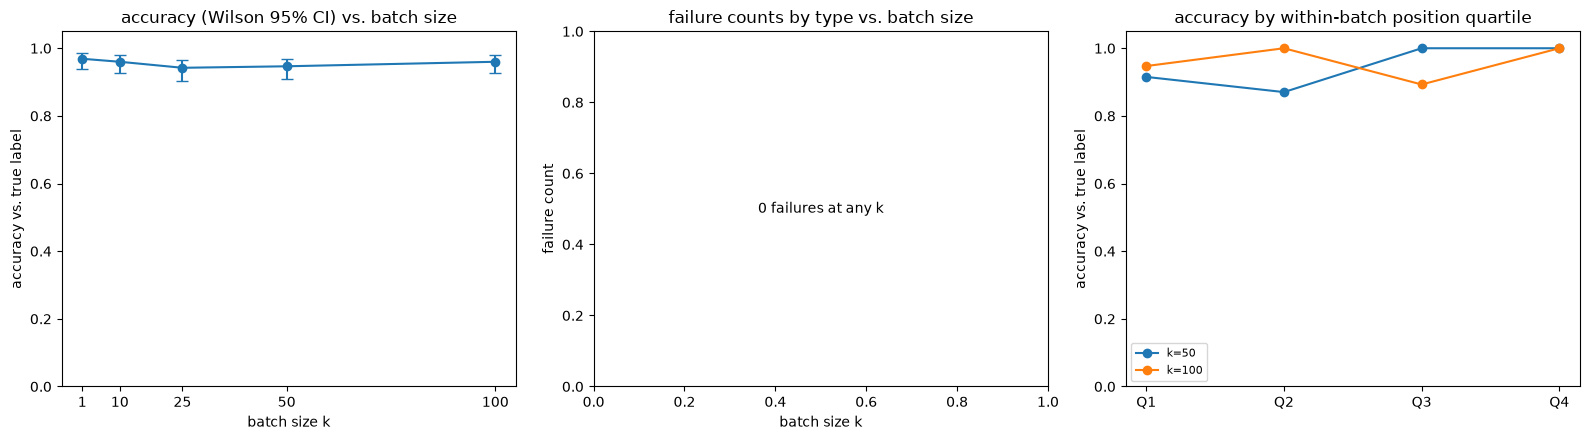

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.5))

ks = sorted(BATCH_SWEEP.keys())
accs = [BATCH_SWEEP[k]["accuracy"] for k in ks]
err_lo = [BATCH_SWEEP[k]["accuracy"] - BATCH_SWEEP[k]["ci_lo"] for k in ks]
err_hi = [BATCH_SWEEP[k]["ci_hi"] - BATCH_SWEEP[k]["accuracy"] for k in ks]
ax1.errorbar(ks, accs, yerr=[err_lo, err_hi], fmt="o-", capsize=4, color=PALETTE["estimate"])
ax1.set_xlabel("batch size k")
ax1.set_ylabel("accuracy vs. true label")
ax1.set_title("accuracy (Wilson 95% CI) vs. batch size")
ax1.set_xticks(ks)
ax1.set_ylim(0, 1.05)

failure_types = sorted({ft for row in BATCH_SWEEP.values() for ft in row["failure_counts"]})
if failure_types:
    x = np.arange(len(ks))
    width = 0.8 / max(len(failure_types), 1)
    for i, ft in enumerate(failure_types):
        vals = [BATCH_SWEEP[k]["failure_counts"].get(ft, 0) for k in ks]
        ax2.bar(x + i * width, vals, width, label=ft)
    ax2.set_xticks(x + width * (len(failure_types) - 1) / 2)
    ax2.set_xticklabels(ks)
    ax2.legend(fontsize=8)
else:
    ax2.text(0.5, 0.5, "0 failures at any k", ha="center", va="center", transform=ax2.transAxes)
ax2.set_xlabel("batch size k")
ax2.set_ylabel("failure count")
ax2.set_title("failure counts by type vs. batch size")

quartile_labels = ["Q1", "Q2", "Q3", "Q4"]
xq = np.arange(4)
for k in (50, 100):
    ax3.plot(xq, BATCH_POSITION_ACCURACY[k], marker="o", label=f"k={k}")
ax3.set_xticks(xq)
ax3.set_xticklabels(quartile_labels)
ax3.set_ylabel("accuracy vs. true label")
ax3.set_title("accuracy by within-batch position quartile")
ax3.set_ylim(0, 1.05)
ax3.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. End-to-end hybrid pipeline

Now the full corpus: rules decide `pos`/`neg` outright; anything `unresolved` goes to
`classify_postings(k=10)`. Items that still fail after repair (`status='failed'`) fall back to
the rule tier's own score using a relaxed midpoint threshold (`rule_score >= 2.0`, halfway
between `lo=0` and `hi=4`) rather than the strict pos/neg thresholds -- since by construction
these records didn't clear either strict threshold, this is a **documented simplification**
(there wasn't a fully specified fallback rule upstream for records the rule tier itself couldn't
resolve; this is the choice made here, flagged explicitly as an audit finding, not a hidden
default). `decided_by` records which of the four paths produced the final label: `rule_pos`,
`rule_neg`, `llm`, `fallback_rule`.

In [10]:
UNRESOLVED = [p for p in ALL_POSTINGS if RULE_DECISIONS[p["id"]] == "unresolved"]
print(f"sending {len(UNRESOLVED)} unresolved postings to the LLM tier (k=10)...")

FAILURE_COUNTS.clear()
_stats_before_pipeline = dict(LLM_STATS)
_ledger_before_pipeline = len(USAGE_LEDGER)
LLM_RESULTS = classify_postings(UNRESOLVED, k=10, section="pipeline")

PIPELINE = {}
FALLBACK_MIDPOINT = (4.0 + 0.0) / 2  # halfway between lo and hi; see markdown above
for p in ALL_POSTINGS:
    dec = RULE_DECISIONS[p["id"]]
    if dec == "pos":
        PIPELINE[p["id"]] = {"final_label": 1, "decided_by": "rule_pos"}
    elif dec == "neg":
        PIPELINE[p["id"]] = {"final_label": 0, "decided_by": "rule_neg"}
    else:
        r = LLM_RESULTS[p["id"]]
        if r["status"] == "failed":
            fb_label = 1 if RULE_SCORES[p["id"]] >= FALLBACK_MIDPOINT else 0
            PIPELINE[p["id"]] = {"final_label": fb_label, "decided_by": "fallback_rule"}
        else:
            PIPELINE[p["id"]] = {"final_label": int(r["genai_substantive"]), "decided_by": "llm"}

DECIDED_BY_ORDER = ["rule_pos", "rule_neg", "llm", "fallback_rule"]
coverage = Counter(v["decided_by"] for v in PIPELINE.values())
print("\ncoverage by decided_by:")
for d in DECIDED_BY_ORDER:
    n = coverage[d]
    print(f"  {d:<14} {n:>5}  ({n/len(ALL_POSTINGS):.1%})")

pipeline_ledger_entries = USAGE_LEDGER[_ledger_before_pipeline:]
print("\nLLM_STATS (session spend -- this run only, ~0 on a warm-cache re-run):", LLM_STATS)
print(f"session spend so far (peak pricing): ${llm_cost_usd(LLM_STATS, peak=True):.4f}")
print(f"ledger cost of THIS section's classification work (survives cache re-runs): "
      f"${ledger_cost_usd(pipeline_ledger_entries, peak=True):.4f}")
print(f"ledger cost of ALL classification work so far: ${ledger_cost_usd(USAGE_LEDGER, peak=True):.4f}")
print(f"\nfailure taxonomy for this section's LLM calls: {dict(FAILURE_COUNTS)}")

sending 1262 unresolved postings to the LLM tier (k=10)...

coverage by decided_by:
  rule_pos        1035  (21.6%)
  rule_neg        2503  (52.1%)
  llm             1262  (26.3%)
  fallback_rule      0  (0.0%)

LLM_STATS (session spend -- this run only, ~0 on a warm-cache re-run): {'live_calls': 0, 'cache_hits': 393, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 80990}
session spend so far (peak pricing): $0.0000
ledger cost of THIS section's classification work (survives cache re-runs): $0.1503
ledger cost of ALL classification work so far: $0.2722

failure taxonomy for this section's LLM calls: {}


#### How to read this chart

Left: how many of the 4,800 postings each tier decided -- `rule_pos`/`rule_neg` are free
(no API call), `llm` is a real DeepSeek call, `fallback_rule` is the (hopefully small) sliver
that failed validation twice. A healthy pipeline has most volume resolved by rules (cheap) and
only the genuinely ambiguous slice paying for an LLM call. Right: **ledger** cost so far by
section -- unlike a raw session-spend chart (which would show \$0 on a cache-warm re-run), the
ledger records what every classification actually cost when it was first produced, live or
cached, so this bar survives re-runs and is the honest "what did this analysis cost" number.

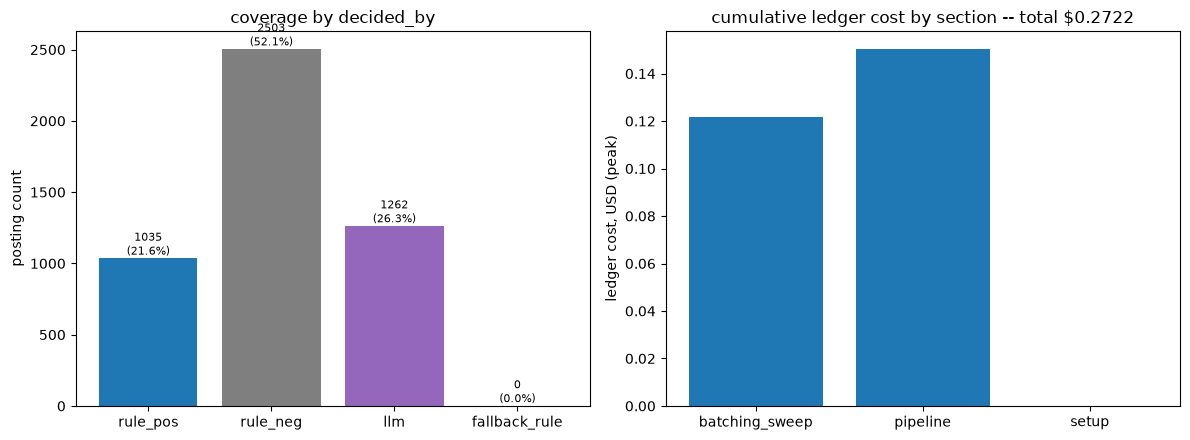

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

decided_colors = [PALETTE[d] for d in DECIDED_BY_ORDER]
vals = [coverage[d] for d in DECIDED_BY_ORDER]
ax1.bar(DECIDED_BY_ORDER, vals, color=decided_colors)
for i, v in enumerate(vals):
    ax1.text(i, v, f"{v}\n({v/len(ALL_POSTINGS):.1%})", ha="center", va="bottom", fontsize=8)
ax1.set_ylabel("posting count")
ax1.set_title("coverage by decided_by")

_sections_so_far = sorted({e["section"] for e in USAGE_LEDGER})
_section_costs = [ledger_cost_usd([e for e in USAGE_LEDGER if e["section"] == s], peak=True)
                   for s in _sections_so_far]
ax2.bar(_sections_so_far, _section_costs, color=PALETTE["estimate"])
ax2.set_ylabel("ledger cost, USD (peak)")
ax2.set_title(f"cumulative ledger cost by section -- total ${sum(_section_costs):.4f}")
fig.tight_layout()
plt.show()

## 6. Audit baseline on a simulated human gold sample

A real audit would sample n≈300 postings, get them human-labeled, and compare the
pipeline's `final_label` against those human labels. Here, labels = the latent `label` --
**stating explicitly: this treats the human annotator as perfect, a simplification** real audits
cannot make (human labelers disagree with each other and with any fixed definition). Precision,
recall, and F1 are reported with **Wilson 95% CIs**, overall and split by `decided_by`. Because
this corpus is synthetic, the **true population values** (computed on all 4,800 records, which a
real audit never gets to see) are printed alongside the n=300 estimates, so this notebook can
show something a real audit can't: whether the 95% CI actually covers the truth.

**i.i.d. sampling and reposts:** the n=300 sample below is drawn **uniformly from all 4,800
records, including the ~20% that are near-duplicate reposts of an earlier posting**. Both the
classical Wilson interval used here and PPI (prediction-powered inference, Notebook 3) rely on
i.i.d. sampling -- PPI's own paper states plainly: *"we assume that (X,Y) and (X̃,Ỹ) are
independently and identically distributed samples from a common distribution, P."* A repost is
not an independent draw of the underlying population; it's the same latent posting resampled.
This audit does **not** correct for that (a known, stated limitation -- see `## Recap`); Notebook
3 deduplicates (MinHash) before sampling.

**The prompt was fixed a priori:** `LABEL_GUIDE`
and `SYSTEM_PROMPT` were written once, in `## 1` / `## 3` above, before this audit sample was ever
drawn or scored -- neither was adjusted after looking at which audit-sample postings the pipeline
got wrong. PPI requires exactly this: *"the prediction rule f is independent of the observed
data"* it's evaluated against. That's what licenses Notebook 3 to reuse this notebook's LLM
labels as PPI's predictor `f` against a **disjoint** future human-labeled sample, rather than
having to retrain or re-validate the prompt first.

In [12]:
def precision_recall_f1(records, pipeline):
    tp = sum(1 for p in records if pipeline[p["id"]]["final_label"] == 1 and p["label"] == 1)
    fp = sum(1 for p in records if pipeline[p["id"]]["final_label"] == 1 and p["label"] == 0)
    fn = sum(1 for p in records if pipeline[p["id"]]["final_label"] == 0 and p["label"] == 1)
    tn = sum(1 for p in records if pipeline[p["id"]]["final_label"] == 0 and p["label"] == 0)
    precision = tp / (tp + fp) if (tp + fp) > 0 else None
    recall = tp / (tp + fn) if (tp + fn) > 0 else None
    f1 = (2 * precision * recall / (precision + recall)
          if (precision is not None and recall is not None and (precision + recall) > 0) else None)
    return {"n": len(records), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": precision, "recall": recall, "f1": f1}


def with_cis(m):
    m = dict(m)
    m["precision_ci"] = wilson_ci(m["tp"], m["tp"] + m["fp"]) if (m["tp"] + m["fp"]) > 0 else None
    m["recall_ci"] = wilson_ci(m["tp"], m["tp"] + m["fn"]) if (m["tp"] + m["fn"]) > 0 else None
    return m


AUDIT_RNG = np.random.default_rng(SEED + 200)
_audit_idx = AUDIT_RNG.choice(len(ALL_POSTINGS), size=300, replace=False)
AUDIT_SAMPLE = [ALL_POSTINGS[i] for i in _audit_idx]

AUDIT_METRICS = with_cis(precision_recall_f1(AUDIT_SAMPLE, PIPELINE))
POPULATION_METRICS = precision_recall_f1(ALL_POSTINGS, PIPELINE)

print(f"AUDIT SAMPLE (n={AUDIT_METRICS['n']}):")
print(f"  precision = {AUDIT_METRICS['precision']:.3f}  95% CI {fmt_ci(AUDIT_METRICS['precision_ci'])}")
print(f"  recall    = {AUDIT_METRICS['recall']:.3f}  95% CI {fmt_ci(AUDIT_METRICS['recall_ci'])}")
print(f"  f1        = {AUDIT_METRICS['f1']:.3f}  (no Wilson CI -- F1 isn't a simple binomial "
      f"proportion; reported as a point estimate only, a deliberate simplification)")

print(f"\nTRUE POPULATION (n={POPULATION_METRICS['n']}, all records -- not available to a real audit):")
print(f"  precision = {POPULATION_METRICS['precision']:.3f}")
print(f"  recall    = {POPULATION_METRICS['recall']:.3f}")
print(f"  f1        = {POPULATION_METRICS['f1']:.3f}")

prec_covered = AUDIT_METRICS["precision_ci"][0] <= POPULATION_METRICS["precision"] <= AUDIT_METRICS["precision_ci"][1]
rec_covered = AUDIT_METRICS["recall_ci"][0] <= POPULATION_METRICS["recall"] <= AUDIT_METRICS["recall_ci"][1]
print(f"\ndoes the audit's 95% CI cover the true population value?")
print(f"  precision: {prec_covered}   recall: {rec_covered}")

print(f"\naudit metrics split by decided_by:")
AUDIT_BY_TIER = {}
for d in DECIDED_BY_ORDER:
    subset = [p for p in AUDIT_SAMPLE if PIPELINE[p["id"]]["decided_by"] == d]
    if not subset:
        print(f"  {d:<14} n=0 (no audit-sample postings landed here)")
        continue
    m = with_cis(precision_recall_f1(subset, PIPELINE))
    AUDIT_BY_TIER[d] = m
    prec_str = f"{m['precision']:.3f} {fmt_ci(m['precision_ci'])}" if m["precision"] is not None else "n/a (0 predicted positive)"
    rec_str = f"{m['recall']:.3f} {fmt_ci(m['recall_ci'])}" if m["recall"] is not None else "n/a (0 true positive)"
    print(f"  {d:<14} n={m['n']:<4} precision={prec_str}  recall={rec_str}")
print("  (note: rule_pos predicts positive for every member by construction, so its recall is "
      "trivially 1.0 -- and symmetrically rule_neg's precision is undefined/n/a. The informative "
      "number in each row is the *other* metric.)")

AUDIT SAMPLE (n=300):
  precision = 0.576  95% CI [0.456, 0.688]
  recall    = 0.745  95% CI [0.611, 0.845]
  f1        = 0.650  (no Wilson CI -- F1 isn't a simple binomial proportion; reported as a point estimate only, a deliberate simplification)

TRUE POPULATION (n=4800, all records -- not available to a real audit):
  precision = 0.606
  recall    = 0.793
  f1        = 0.687

does the audit's 95% CI cover the true population value?
  precision: True   recall: True

audit metrics split by decided_by:
  rule_pos       n=55   precision=0.491 [0.364, 0.619]  recall=1.000 [0.875, 1.000]
  rule_neg       n=170  precision=n/a (0 predicted positive)  recall=0.000 [0.000, 0.228]
  llm            n=75   precision=1.000 [0.741, 1.000]  recall=1.000 [0.741, 1.000]
  fallback_rule  n=0 (no audit-sample postings landed here)
  (note: rule_pos predicts positive for every member by construction, so its recall is trivially 1.0 -- and symmetrically rule_neg's precision is undefined/n/a. The informat

#### How to read this chart

Each blue dot is the n=300 audit's point estimate with its Wilson 95% CI error bar; the red
diamond is the true population value (computed on all 4,800 records -- something a real audit
never has). If the red diamond sits inside the blue error bar, the audit's CI **covered** the
truth at this sample size; if it sits outside, the audit -- despite being a valid 95% procedure
-- happened to miss this time (which will happen roughly 1 time in 20 by construction, precisely
why a single audit result should never be read as certain). F1 is shown as a point only (no
error bar), since a Wilson interval doesn't apply to it directly.

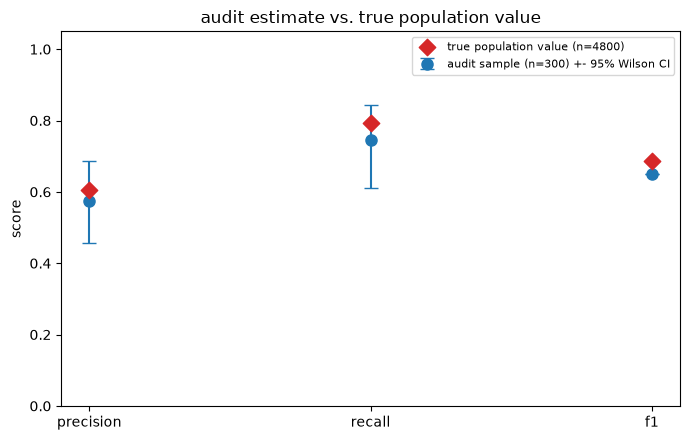

In [13]:
metrics_names = ["precision", "recall", "f1"]
audit_vals = [AUDIT_METRICS[m] for m in metrics_names]
audit_los = [AUDIT_METRICS[m] - AUDIT_METRICS[f"{m}_ci"][0] if AUDIT_METRICS.get(f"{m}_ci") else 0 for m in metrics_names]
audit_his = [AUDIT_METRICS[f"{m}_ci"][1] - AUDIT_METRICS[m] if AUDIT_METRICS.get(f"{m}_ci") else 0 for m in metrics_names]
pop_vals = [POPULATION_METRICS[m] for m in metrics_names]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(metrics_names))
ax.errorbar(x, audit_vals, yerr=[audit_los, audit_his], fmt="o", capsize=5, markersize=8,
            color=PALETTE["estimate"], label="audit sample (n=300) +- 95% Wilson CI")
ax.scatter(x, pop_vals, marker="D", s=70, color=PALETTE["truth"], zorder=5,
           label="true population value (n=4800)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("audit estimate vs. true population value")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 7. Where are rules the right tool? Boundary diagnostics

Three angles on the same question -- where should the rules/LLM boundary move. **All of this
section is this notebook's own empirical exercise: it is not derived from, or a claim about,
PPI, BARGAIN, or PPRM** (that would misapply BARGAIN's static-batch cascade-threshold machinery
to a question it wasn't built to answer here; the resemblance is only superficial).

**(a)** Break `rule_score` into bins and look at the true-positive purity of each bin -- this is
the finer-grained version of the pos/neg/unresolved split, showing whether scores just above the
`hi=4.0` threshold are as trustworthy as very high scores.

**(b)** **LLM-label every posting** (not just a probe) -- the `unresolved` postings already have
an LLM label from `## 5`; this section additionally sends the remaining (rule-resolved)
postings through `classify_postings(k=10)` too, purely for this audit, so every one of the 4,800
postings has both a rule decision and an LLM label. That lets rules-vs-LLM accuracy be computed
**exactly**, by score bin and by latent class, instead of estimated from a small probe. The
rules-only series below uses the pipeline's actual fallback (`rule_score >= 2.0`) for postings
the rules left `unresolved`, instead of silently scoring them as automatic misses.

**(c)** A **boundary sweep**: re-run the whole pipeline for `hi` in `{1, ..., 12}` (`lo=0` fixed)
-- `score >= hi` to rule `pos`, `score <= lo` to rule `neg`, everything else to the LLM label
already computed in (b) -- and plot the resulting pipeline error rate against the % of postings
that would be sent to the LLM at that `hi`. This uses no new API calls (every needed LLM label
already exists from (b)); it only changes which decisions come from rules vs. the LLM. The
notebook's actual `hi=4.0` is marked on the curve.

In [14]:
BIN_EDGES = [0.0, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
BIN_LABELS = ["<=0", "(0,1]", "(1,2]", "(2,3]", "(3,4]", "(4,6]", "(6,8]", ">8"]


def bin_index(score, edges=BIN_EDGES):
    for i, e in enumerate(edges):
        if score <= e:
            return i
    return len(edges)


def bin_label_for(score):
    return BIN_LABELS[bin_index(score)]


print(f"{'bin':<8}{'n':>6}{'label=1':>9}{'purity(label=1 rate)':>24}{'pos':>6}{'neg':>6}{'unresolved':>12}")
BIN_STATS = {}
for i, lbl in enumerate(BIN_LABELS):
    bucket = [p for p in ALL_POSTINGS if bin_index(RULE_SCORES[p["id"]]) == i]
    n = len(bucket)
    n1 = sum(p["label"] for p in bucket)
    dec_counts = Counter(RULE_DECISIONS[p["id"]] for p in bucket)
    purity = n1 / n if n else float("nan")
    BIN_STATS[lbl] = {"n": n, "n1": n1, "purity": purity, "dec_counts": dict(dec_counts)}
    print(f"{lbl:<8}{n:>6}{n1:>9}{purity:>24.3f}{dec_counts.get('pos',0):>6}"
          f"{dec_counts.get('neg',0):>6}{dec_counts.get('unresolved',0):>12}")

RULES_ONLY = precision_recall_f1(
    ALL_POSTINGS,
    {p["id"]: {"final_label": 1 if RULE_DECISIONS[p["id"]] == "pos" else 0} for p in ALL_POSTINGS},
)
print(f"\nrules-only (pos=1, neg/unresolved=0) vs. truth, whole corpus:")
print(f"  precision={RULES_ONLY['precision']:.3f}  recall={RULES_ONLY['recall']:.3f}  f1={RULES_ONLY['f1']:.3f}")

bin          n  label=1    purity(label=1 rate)   pos   neg  unresolved
<=0       2503      186                   0.074     0  2503           0
(0,1]      168       16                   0.095     0     0         168
(1,2]      295       83                   0.281     0     0         295
(2,3]      568       96                   0.169     0     0         568
(3,4]      236       19                   0.081     5     0         231
(4,6]      325       60                   0.185   325     0           0
(6,8]      155       45                   0.290   155     0           0
>8         550      442                   0.804   550     0           0



rules-only (pos=1, neg/unresolved=0) vs. truth, whole corpus:
  precision=0.529  recall=0.578  f1=0.552


In [15]:
RESOLVED = [p for p in ALL_POSTINGS if RULE_DECISIONS[p["id"]] != "unresolved"]
print(f"LLM-labeling the remaining {len(RESOLVED)} rule-resolved postings (k=10) "
      f"so every posting has an LLM label (audit-only spend; the real pipeline in ## 5 "
      f"never sends these to the LLM)...")

FAILURE_COUNTS.clear()
RESOLVED_LLM_RESULTS = classify_postings(RESOLVED, k=10, section="boundary_full_llm")
print(f"full-labeling failure taxonomy: {dict(FAILURE_COUNTS)}")

ALL_LLM_LABELS = dict(LLM_RESULTS)
ALL_LLM_LABELS.update(RESOLVED_LLM_RESULTS)
print(f"ALL_LLM_LABELS now covers {len(ALL_LLM_LABELS)}/{len(ALL_POSTINGS)} postings")


def rules_correct(p):
    # Uses the SAME fallback the pipeline uses for postings rules left unresolved
    # (rule_score >= FALLBACK_MIDPOINT), instead of counting every unresolved posting
    # as an automatic rules error.
    dec = RULE_DECISIONS[p["id"]]
    if dec == "unresolved":
        pred = 1 if RULE_SCORES[p["id"]] >= FALLBACK_MIDPOINT else 0
    else:
        pred = 1 if dec == "pos" else 0
    return pred == p["label"]


def llm_correct(p):
    r = ALL_LLM_LABELS[p["id"]]
    if r["status"] == "failed" or r["genai_substantive"] is None:
        pred = 1 if RULE_SCORES[p["id"]] >= FALLBACK_MIDPOINT else 0  # same fallback if LLM failed
    else:
        pred = int(bool(r["genai_substantive"]))
    return pred == p["label"]


ACCURACY_BY_BIN = {}
for lbl in BIN_LABELS:
    bucket = [p for p in ALL_POSTINGS if bin_label_for(RULE_SCORES[p["id"]]) == lbl]
    if not bucket:
        continue
    ACCURACY_BY_BIN[lbl] = {
        "n": len(bucket),
        "rules_acc": sum(rules_correct(p) for p in bucket) / len(bucket),
        "llm_acc": sum(llm_correct(p) for p in bucket) / len(bucket),
    }

print(f"\n{'bin':<8}{'n':>6}{'rules_acc (fallback 2.0)':>26}{'llm_acc':>12}")
for lbl, row in ACCURACY_BY_BIN.items():
    print(f"{lbl:<8}{row['n']:>6}{row['rules_acc']:>26.3f}{row['llm_acc']:>12.3f}")

ERRORS_BY_CLASS_RULES = {}
ERRORS_BY_CLASS_LLM = {}
N_BY_CLASS_ALL = {}
for cls in CLASS_ORDER:
    bucket = [p for p in ALL_POSTINGS if p["latent_class"] == cls]
    N_BY_CLASS_ALL[cls] = len(bucket)
    ERRORS_BY_CLASS_RULES[cls] = sum(1 for p in bucket if not rules_correct(p))
    ERRORS_BY_CLASS_LLM[cls] = sum(1 for p in bucket if not llm_correct(p))

print(f"\n{'latent_class':<20}{'n':>6}{'rules_errors':>14}{'llm_errors':>12}")
for cls in CLASS_ORDER:
    print(f"{cls:<20}{N_BY_CLASS_ALL[cls]:>6}{ERRORS_BY_CLASS_RULES[cls]:>14}{ERRORS_BY_CLASS_LLM[cls]:>12}")

# Findings computed from the numbers above -- not hard-coded.
worst_rules_cls = max(CLASS_ORDER, key=lambda c: ERRORS_BY_CLASS_RULES[c] / max(N_BY_CLASS_ALL[c], 1))
worst_llm_cls = max(CLASS_ORDER, key=lambda c: ERRORS_BY_CLASS_LLM[c] / max(N_BY_CLASS_ALL[c], 1))
total_rules_err = sum(ERRORS_BY_CLASS_RULES.values())
total_llm_err = sum(ERRORS_BY_CLASS_LLM.values())
print(f"\nfindings (computed from the table above, on all {len(ALL_POSTINGS)} postings):")
print(f"  - rules' (with fallback) highest per-posting error RATE among these classes is "
      f"{worst_rules_cls} ({ERRORS_BY_CLASS_RULES[worst_rules_cls]}/{N_BY_CLASS_ALL[worst_rules_cls]} = "
      f"{ERRORS_BY_CLASS_RULES[worst_rules_cls]/N_BY_CLASS_ALL[worst_rules_cls]:.1%}).")
print(f"  - the LLM's highest per-posting error rate among these classes is {worst_llm_cls} "
      f"({ERRORS_BY_CLASS_LLM[worst_llm_cls]}/{N_BY_CLASS_ALL[worst_llm_cls]} = "
      f"{ERRORS_BY_CLASS_LLM[worst_llm_cls]/N_BY_CLASS_ALL[worst_llm_cls]:.1%}).")
print(f"  - total errors across all {len(ALL_POSTINGS)} postings: rules(+fallback)={total_rules_err}, "
      f"LLM={total_llm_err} ({'LLM' if total_llm_err < total_rules_err else 'rules'} makes fewer "
      f"mistakes overall here).")

LLM-labeling the remaining 3538 rule-resolved postings (k=10) so every posting has an LLM label (audit-only spend; the real pipeline in ## 5 never sends these to the LLM)...


full-labeling failure taxonomy: {}
ALL_LLM_LABELS now covers 4800/4800 postings

bin          n  rules_acc (fallback 2.0)     llm_acc
<=0       2503                     0.926       0.994
(0,1]      168                     0.905       0.958
(1,2]      295                     0.529       1.000
(2,3]      568                     0.169       0.996
(3,4]      236                     0.081       0.996
(4,6]      325                     0.185       0.982
(6,8]      155                     0.290       0.981
>8         550                     0.804       0.993

latent_class             n  rules_errors  llm_errors
A_genai_core           462            13           5
B_decorated            503           293           0
C_genai_implicit       236           236           7
D_plain               2163             0           0
E_tool_user            290           263           0
F_mixed_minor          330           176           0
G_mixed_major          249            36          27
H_classic_nlp_ml 

In [16]:
def pipeline_label_for_hi(p, hi, lo=0.0):
    score = RULE_SCORES[p["id"]]
    if score >= hi:
        return 1, "rule_pos"
    if score <= lo:
        return 0, "rule_neg"
    r = ALL_LLM_LABELS[p["id"]]
    if r["status"] == "failed" or r["genai_substantive"] is None:
        return (1 if score >= FALLBACK_MIDPOINT else 0), "fallback_rule"
    return int(bool(r["genai_substantive"])), "llm"


BOUNDARY_SWEEP = {}
for hi in range(1, 13):
    n_errors = 0
    n_to_llm = 0
    for p in ALL_POSTINGS:
        pred, path = pipeline_label_for_hi(p, hi)
        if path in ("llm", "fallback_rule"):
            n_to_llm += 1
        if pred != p["label"]:
            n_errors += 1
    BOUNDARY_SWEEP[hi] = {
        "error_rate": n_errors / len(ALL_POSTINGS),
        "pct_to_llm": n_to_llm / len(ALL_POSTINGS),
    }

print(f"{'hi':>4}{'error_rate':>12}{'%_to_llm':>12}")
for hi, row in BOUNDARY_SWEEP.items():
    marker = "  <-- current hi" if hi == 4 else ""
    print(f"{hi:>4}{row['error_rate']:>12.3f}{row['pct_to_llm']:>12.1%}{marker}")

best_hi = min(BOUNDARY_SWEEP, key=lambda h: BOUNDARY_SWEEP[h]["error_rate"])
print(f"\nlowest pipeline error rate in this sweep: hi={best_hi} "
      f"(error_rate={BOUNDARY_SWEEP[best_hi]['error_rate']:.3f}, "
      f"%_to_llm={BOUNDARY_SWEEP[best_hi]['pct_to_llm']:.1%}) vs. "
      f"current hi=4 (error_rate={BOUNDARY_SWEEP[4]['error_rate']:.3f}, "
      f"%_to_llm={BOUNDARY_SWEEP[4]['pct_to_llm']:.1%}).")

  hi  error_rate    %_to_llm
   1       0.331        3.3%
   2       0.296        8.5%
   3       0.239       15.0%
   4       0.142       26.3%  <-- current hi
   5       0.105       30.4%
   6       0.096       32.1%
   7       0.076       34.9%
   8       0.068       36.1%
   9       0.061       37.1%
  10       0.052       38.2%
  11       0.048       38.8%
  12       0.046       39.2%

lowest pipeline error rate in this sweep: hi=12 (error_rate=0.046, %_to_llm=39.2%) vs. current hi=4 (error_rate=0.142, %_to_llm=26.3%).


#### How to read this chart

Left: accuracy vs. true label by `rule_score` bin, rules-with-fallback (blue) vs. LLM (red), on
**all 4,800 postings** -- the rules series now uses the pipeline's actual `score >= 2.0` fallback
for the unresolved bins instead of scoring them as automatic misses, so this is a fair
comparison, not a strawman. If the red line sits above the blue line in the low/mid bins, that's
direct evidence the LLM should own more of the score range than it currently does. Middle: total
error counts by latent class, same population, same two tiers side by side -- tall blue bars mark
which latent classes the rule tier (with fallback) structurally cannot handle; tall red bars mark
where the LLM itself still struggles. Right: the **boundary sweep tradeoff curve** -- x is the %
of postings sent to the LLM at a given `hi` threshold, y is the resulting pipeline error rate;
each point is one `hi` from 1 to 12, and the current `hi=4.0` is marked in red. A curve that
keeps dropping to the right means paying for more LLM calls keeps buying lower error; a flat or
rising tail means the extra spend stops being worth it (or actively hurts, if the LLM's own
errors dominate at that point).

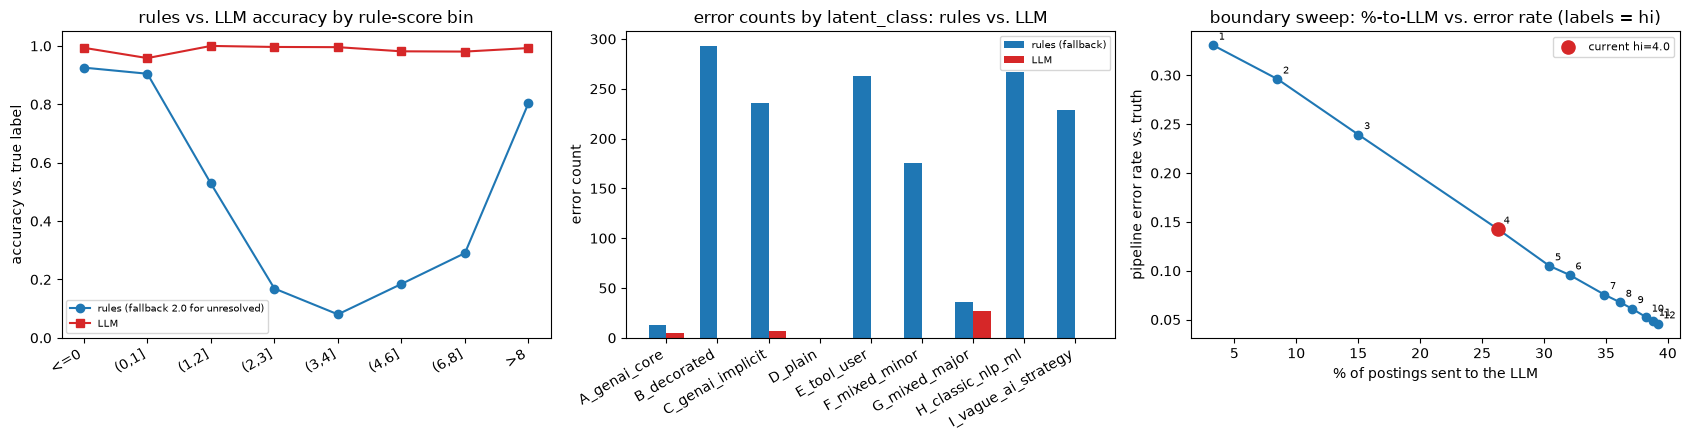

In [17]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.5))

present_bins = [b for b in BIN_LABELS if b in ACCURACY_BY_BIN]
rules_acc = [ACCURACY_BY_BIN[b]["rules_acc"] for b in present_bins]
llm_acc = [ACCURACY_BY_BIN[b]["llm_acc"] for b in present_bins]
xb = np.arange(len(present_bins))
ax1.plot(xb, rules_acc, marker="o", label="rules (fallback 2.0 for unresolved)", color=PALETTE["rules"])
ax1.plot(xb, llm_acc, marker="s", label="LLM", color=PALETTE["llm_line"])
ax1.set_xticks(xb)
ax1.set_xticklabels(present_bins, rotation=30, ha="right")
ax1.set_ylabel("accuracy vs. true label")
ax1.set_ylim(0, 1.05)
ax1.set_title("rules vs. LLM accuracy by rule-score bin")
ax1.legend(fontsize=7)

xc = np.arange(len(CLASS_ORDER))
width = 0.35
ax2.bar(xc - width / 2, [ERRORS_BY_CLASS_RULES[c] for c in CLASS_ORDER], width,
        label="rules (fallback)", color=PALETTE["rules"])
ax2.bar(xc + width / 2, [ERRORS_BY_CLASS_LLM[c] for c in CLASS_ORDER], width,
        label="LLM", color=PALETTE["llm_line"])
ax2.set_xticks(xc)
ax2.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax2.set_ylabel("error count")
ax2.set_title("error counts by latent_class: rules vs. LLM")
ax2.legend(fontsize=7)

his = sorted(BOUNDARY_SWEEP.keys())
xs = [BOUNDARY_SWEEP[h]["pct_to_llm"] * 100 for h in his]
ys = [BOUNDARY_SWEEP[h]["error_rate"] for h in his]
ax3.plot(xs, ys, marker="o", color=PALETTE["estimate"])
for h, x, y in zip(his, xs, ys):
    ax3.annotate(str(h), (x, y), fontsize=7, textcoords="offset points", xytext=(4, 4))
cur_x, cur_y = BOUNDARY_SWEEP[4]["pct_to_llm"] * 100, BOUNDARY_SWEEP[4]["error_rate"]
ax3.scatter([cur_x], [cur_y], color=PALETTE["current_hi"], s=90, zorder=5, label="current hi=4.0")
ax3.set_xlabel("% of postings sent to the LLM")
ax3.set_ylabel("pipeline error rate vs. truth")
ax3.set_title("boundary sweep: %-to-LLM vs. error rate (labels = hi)")
ax3.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 8. Results summary

One compact table pulling together the numbers computed in `## 4`-`## 7`.

In [18]:
print("=" * 72)
print("PHASE-1 AUDIT BASELINE -- RESULTS SUMMARY")
print("=" * 72)
print(f"corpus: {len(ALL_POSTINGS)} postings ({len(ALL_POSTINGS) - reposts} unique, {reposts} reposts), "
      f"{len(MONTHS)} months, {len(CLASS_ORDER)} latent classes, seed={SEED}")
print(f"rule tier: {n_unresolved}/{len(ALL_POSTINGS)} unresolved ({n_unresolved/len(ALL_POSTINGS):.1%})")
print(f"batching sweep (n=225, 25/class): " +
      ", ".join(f"k={k} acc={BATCH_SWEEP[k]['accuracy']:.3f}" for k in sorted(BATCH_SWEEP)))
print(f"pipeline coverage: " + ", ".join(f"{d}={coverage[d]}" for d in DECIDED_BY_ORDER))
print(f"LLM_STATS (session spend): {LLM_STATS}")
print(f"session spend so far (peak): ${llm_cost_usd(LLM_STATS, peak=True):.4f}")
print(f"LEDGER cost of all classification work so far (peak, survives cache re-runs): "
      f"${ledger_cost_usd(USAGE_LEDGER, peak=True):.4f}  ({len(USAGE_LEDGER)} ledger entries)")
print(f"audit (n=300) vs. true population (n={len(ALL_POSTINGS)}):")
print(f"  precision: {AUDIT_METRICS['precision']:.3f} {fmt_ci(AUDIT_METRICS['precision_ci'])} "
      f"vs. true {POPULATION_METRICS['precision']:.3f}  (covered={prec_covered})")
print(f"  recall:    {AUDIT_METRICS['recall']:.3f} {fmt_ci(AUDIT_METRICS['recall_ci'])} "
      f"vs. true {POPULATION_METRICS['recall']:.3f}  (covered={rec_covered})")
print(f"  f1:        {AUDIT_METRICS['f1']:.3f} vs. true {POPULATION_METRICS['f1']:.3f}")
print(f"rules-only (strict, no fallback) precision/recall/f1: {RULES_ONLY['precision']:.3f} / "
      f"{RULES_ONLY['recall']:.3f} / {RULES_ONLY['f1']:.3f}")
print(f"boundary diagnostics: total errors across all {len(ALL_POSTINGS)} postings -- "
      f"rules(+fallback)={total_rules_err}, LLM={total_llm_err}")
print(f"boundary sweep: current hi=4.0 -> error_rate={BOUNDARY_SWEEP[4]['error_rate']:.3f}, "
      f"%_to_llm={BOUNDARY_SWEEP[4]['pct_to_llm']:.1%}; best in sweep hi={best_hi} -> "
      f"error_rate={BOUNDARY_SWEEP[best_hi]['error_rate']:.3f}, "
      f"%_to_llm={BOUNDARY_SWEEP[best_hi]['pct_to_llm']:.1%}")
print("=" * 72)

PHASE-1 AUDIT BASELINE -- RESULTS SUMMARY
corpus: 4800 postings (3840 unique, 960 reposts), 6 months, 9 latent classes, seed=20260917
rule tier: 1262/4800 unresolved (26.3%)
batching sweep (n=225, 25/class): k=1 acc=0.969, k=10 acc=0.960, k=25 acc=0.942, k=50 acc=0.947, k=100 acc=0.960
pipeline coverage: rule_pos=1035, rule_neg=2503, llm=1262, fallback_rule=0
LLM_STATS (session spend): {'live_calls': 0, 'cache_hits': 747, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 195099}
session spend so far (peak): $0.0000
LEDGER cost of all classification work so far (peak, survives cache re-runs): $0.6904  (747 ledger entries)
audit (n=300) vs. true population (n=4800):
  precision: 0.576 [0.456, 0.688] vs. true 0.606  (covered=True)
  recall:    0.745 [0.611, 0.845] vs. true 0.793  (covered=True)
  f1:        0.650 vs. true 0.687
rules-only (strict, no fallback) precision/recall/f1: 0.529 / 0.578 / 0.552
bound

## Recap: what exists now vs. what Notebook 3 adds

**What this notebook built:**
- A synthetic, known-latent-truth job-posting generator (`generate_corpus`) with **9** latent
  classes (including 4 deliberately definition-hard ones), a scripted month-5/6 buzzword wave,
  and ~20% near-duplicate reposts, tuned so rule scores of label-0 and label-1 postings
  genuinely overlap (~26-30% unresolved) rather than being trivially separable.
- A deterministic keyword-taxonomy rule tier (`rule_score`, `rule_decision`) and its
  tier x latent-class contingency table.
- A **real** DeepSeek (`deepseek-flash`) HTTP client (`deepseek_chat`) with disk caching,
  retries, a hard live-call budget, cost accounting (`llm_cost_usd`), and a `USAGE_LEDGER` /
  `ledger_cost_usd` that records what every classification cost when it was first produced
  (survives cache-warm re-runs), plus a validated/repaired batch classifier (`classify_batch`,
  `classify_postings`) built on pydantic.
- A batching-strategy sweep (k in {1,10,25,50,100}, n=225) with Wilson-CI accuracy, a failure
  taxonomy, and accuracy by within-batch position quartile.
- The full hybrid pipeline (rules -> unresolved -> LLM -> fallback) with `decided_by` coverage.
- An audit baseline: precision/recall/F1 with Wilson 95% CIs on a simulated n=300 human
  audit, checked against the true population values available only because the corpus is
  synthetic -- with an explicit note that the audit sample is **not** i.i.d. (it includes
  reposts) and that the LLM prompt was fixed before the audit was ever run.
- Boundary diagnostics: rule-score-bin purity, an exact (not probe-sampled) rules-vs-LLM
  comparison over all 4,800 postings, error counts by latent class, and an empirical **boundary
  sweep** over `hi in {1,...,12}` trading off % sent to the LLM against pipeline error rate.

**What Notebook 3 will add**, reusing the generator, rules, client, and classify functions above
verbatim:
- **BARGAIN**-style guaranteed routing between a cheap proxy (DeepSeek non-thinking, logprob
  confidence) and an oracle (DeepSeek with thinking enabled) -- BARGAIN (Zeighami, Shankar,
  Parameswaran, arXiv:2509.02896) formalizes exactly this cascade-threshold routing problem with
  a statistical guarantee on the resulting accuracy/precision/recall **relative to the oracle's
  own outputs, not human ground truth** -- a distinction Notebook 3 will need to be explicit
  about. That guarantee is defined **on a static batch of data**: BARGAIN's own paper does not
  give a rule for adapting the cascade threshold under streaming drift, so Notebook 3 would
  certify routing on a fixed batch (e.g. one month's `unresolved` postings), not continuously.
- **PPI** (prediction-powered inference; Angelopoulos, Bates, Fannjiang, Jordan, Zrnic,
  *Science* 2023, arXiv:2301.09633) for monthly precision/prevalence estimation against a small
  human audit, in place of this notebook's plain Wilson-CI audit sample.
- **PPRM**-style monitoring (Zhang, Cai, Yu, Simeone, ICML 2026, arXiv:2602.02229) for
  anytime-valid harmful-drift alarms on the month-5/6 buzzword wave -- PPRM alarms specifically
  on a **harmful** increase in running risk (not on distribution change in general), needs at
  least one label per time step, and its own paper's default miscoverage budget is
  δ_S=0.05 / δ_T=0.2 (δ=0.25 total). Its guarantee holds simultaneously over all future time
  steps (not just at one fixed sample size), which is the property this notebook's single-shot
  n=300 audit above does not have.
- MinHash dedup before audit sampling (this notebook's ~20% repost rate is currently ignored by
  the n=300 sampler, which can draw both a posting and its repost -- see `## 6`).
- Fuller cost accounting across the routing/audit/monitoring stack, building on this notebook's
  `USAGE_LEDGER`.
- **A caveat worth stating plainly: no paper here provides a unified monthly lifecycle combining
  BARGAIN routing, PPI estimation, and PPRM monitoring.** Stitching the three together into one
  monthly cycle is this project's own design choice, not a claim sourced from any of the three
  papers -- Notebook 3 should say so explicitly wherever it presents that architecture.

**Extension ideas (deliberately left open):**
- Real dataset & sampling -- swap the synthetic generator for the real LinkedIn postings dataset
  (or another real corpus), and decide the real audit sample size/cadence.
- The `genai_substantive` label definition itself -- `LABEL_GUIDE` above is one reasonable
  reading of "substantive GenAI work"; a real stakeholder conversation could easily redraw it,
  especially at the `E_tool_user` boundary.
- Real human annotators & budget for the audit (this notebook's "perfect annotator" is a
  simplification real audits cannot make).
- Provider/model choice -- a real deployment might call Claude; this notebook uses DeepSeek
  (`deepseek-flash`) because it is cheap enough to label every posting for real while prototyping.
  `## 3`'s mapping table is the starting point for swapping in Claude.
- Batch size policy -- `## 4`'s sweep is a starting point, not a final answer, at n=225.
- The `fallback_rule` midpoint threshold introduced in `## 5` (a choice this notebook had to
  make that wasn't fully specified upstream) -- worth deciding deliberately rather than
  inheriting; `## 7`'s boundary sweep is a first empirical look at moving it.
- `MAX_LIVE_CALLS` (raised to 2500 in this revision so `## 7` could label every posting) --
  a real deployment should size this to its actual monthly `unresolved` volume, not to what an
  audit notebook needed once.
- Report format -- this notebook's numbers, not a written audit assessment for stakeholders.

## Appendix: cache housekeeping

Not part of the audit narrative above -- a small maintenance utility. Every cache key this run
touched (live call or cache hit) was recorded in `USED_CACHE_KEYS` as the notebook ran. This
writes that set to disk so a maintainer can prune cache files nothing in the current notebook
references (e.g. after a prompt or corpus change makes old cached requests stale) without
guessing. It does not delete anything itself.

In [19]:
_referenced_path = CACHE_DIR.parent / "_referenced_keys.json"
_referenced_path.parent.mkdir(parents=True, exist_ok=True)
with open(_referenced_path, "w") as f:
    json.dump(sorted(USED_CACHE_KEYS), f)
print(f"wrote {len(USED_CACHE_KEYS)} referenced cache keys to {_referenced_path.relative_to(NOTEBOOK_DIR.parent)}")

wrote 745 referenced cache keys to data/llm_cache/_referenced_keys.json
